# Projet 10 : Modélisez les ventes d'un ensemble de magasin 

# Sommaire

1. Explorez le jeu de données

2. Caractérisez les différentes typologies de magasin

3. Construisez un modèle de prévision des ventes

4. Évaluez la performance du modèle de prévision sur les différents groupes de magasin 

## 1 Explorez le jeu de données

In [27]:
#Import des librairies
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np

In [29]:
#Afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)

In [31]:
#Ne pas afficher l'avertissement concernant openpyxl
import warnings
warnings.simplefilter("ignore")

## 2 Analyse exploratoire du fichier train

In [42]:
#Chargement du fichier train
df_train = pd.read_csv("train.csv", low_memory=False)

In [46]:
#Afficher les dimensions du dataset
df_train.shape()

Le tableau comporte 1017209 observations ou articles
Le tableau comporte 9 colonnes


In [48]:
#Afficher les informations
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [50]:
#Afficher le dataframe
df_train

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [188]:
#Afficher les valeurs manquantes par colonne en pourcentage
df_train.isna().mean()

Store            0.0
DayOfWeek        0.0
Date             0.0
Sales            0.0
Customers        0.0
Open             0.0
Promo            0.0
StateHoliday     0.0
SchoolHoliday    0.0
année            0.0
mois             0.0
jour             0.0
mois_nom         0.0
jour_nom         0.0
dtype: float64

In [52]:
#Affichage des données statistiques des ventes
#Permet d'avoir une idée de la dispersion globale des données de train
df_train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [54]:
#Calculer la moyenne de la colonne Sales
moyenne_ventes = df_train["Sales"].mean()
print(f"La moyenne des ventes est de : {moyenne_ventes}")

La moyenne des ventes est de : 5773.818972305593


In [56]:
#Calculer la somme des ventes
somme_ventes = df_train["Sales"].sum()
print(f"Le chiffre d'affaires est de : {somme_ventes}")

Le chiffre d'affaires est de : 5873180623


## 1.2 Analyse exploratoire du fichier store

In [471]:
#Chargement du fichier store
df_store = pd.read_csv("store.csv", low_memory=False)

In [65]:
#Afficher les dimensions du dataset
df_store.shape()

Le tableau comporte 1115 observations ou articles
Le tableau comporte 10 colonnes


In [473]:
#Afficher les informations
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [69]:
#Afficher les lignes 
df_store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [477]:
# Modification valeurs mois dans colonne promointerval en format numérique numérique
# Et remplacement des valeurs NaN de la colonne promointerval

df_store["PromoInterval"].fillna("0",inplace=True)

# Dictionnaire : 
mois_dic= {
    'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04',
    'May': '05', 'Jun': '06', 'Jul': '07', 'Aug': '08',
    'Sept': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}
# Remplacement des valeurs dans la colonne 
for mois, num in mois_dic.items():
    df_store['PromoInterval'] = df_store['PromoInterval'].str.replace(mois, num)

# Changement types colonnes
df_store['PromoInterval'] = df_store['PromoInterval'].astype("str")

df_store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"01,04,07,10"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"01,04,07,10"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,0
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"01,04,07,10"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,0
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,0
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,0


In [479]:
#Afficher les valeurs manquantes par colonne en pourcentage
df_store.isna().mean()

Store                        0.000000
StoreType                    0.000000
Assortment                   0.000000
CompetitionDistance          0.002691
CompetitionOpenSinceMonth    0.317489
CompetitionOpenSinceYear     0.317489
Promo2                       0.000000
Promo2SinceWeek              0.487892
Promo2SinceYear              0.487892
PromoInterval                0.000000
dtype: float64

In [71]:
#Affichage des données statistiques des magasins
df_store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [481]:
#Afficher les différents types de magasins
df_store['StoreType'].unique()

array(['c', 'a', 'd', 'b'], dtype=object)

In [487]:
# Vérification des modifications du store
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              1115 non-null   object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


## 1.3 Analyse exploratoire du fichier test

In [78]:
#Chargement du fichier test
df_test = pd.read_csv("test.csv", low_memory=False)

In [80]:
#Afficher les dimensions du dataset
df_test.shape()

Le tableau comporte 41088 observations ou articles
Le tableau comporte 8 colonnes


In [489]:
#Afficher les informations
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             41088 non-null  int64 
 1   Store          41088 non-null  int64 
 2   DayOfWeek      41088 non-null  int64 
 3   Date           41088 non-null  object
 4   Open           41088 non-null  int64 
 5   Promo          41088 non-null  int64 
 6   StateHoliday   41088 non-null  int64 
 7   SchoolHoliday  41088 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 2.5+ MB


In [453]:
df_test

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [455]:
print(df_test['StateHoliday'].unique())

['0' 'a']


In [457]:
# Remplacement des valeurs de la colonne stateholiday et type colonne

df_test['StateHoliday'] = df_test['StateHoliday'].replace('a', 1)
df_test["StateHoliday"] = df_test['StateHoliday'].astype("int64")

In [201]:
#Afficher les valeurs manquantes par colonne en pourcentage
df_test.isna().mean()

Id               0.000000
Store            0.000000
DayOfWeek        0.000000
Date             0.000000
Open             0.000268
Promo            0.000000
StateHoliday     0.000000
SchoolHoliday    0.000000
dtype: float64

In [459]:
# Remplacement des valeurs de la colonne Open et type colonne

df_test["Open"].fillna(33,inplace=True)
df_test["Open"] = df_test['Open'].astype(int)

In [ ]:
# Passage de date en datetime

df_test["Date"] = pd.to_datetime(df_test["Date"])

In [461]:
# Confirmation des modifications apportées

df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             41088 non-null  int64 
 1   Store          41088 non-null  int64 
 2   DayOfWeek      41088 non-null  int64 
 3   Date           41088 non-null  object
 4   Open           41088 non-null  int64 
 5   Promo          41088 non-null  int64 
 6   StateHoliday   41088 non-null  int64 
 7   SchoolHoliday  41088 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 2.5+ MB


## 1.4 Analyse rapide et chargement du fichier sample

In [89]:
#Chargement du fichier
df_sub = pd.read_csv("sample_submission.csv", low_memory=False)

In [95]:
#Afficher les dimensions du dataset
df_sub.shape()

Le tableau comporte 41088 observations ou articles
Le tableau comporte 2 colonnes


In [91]:
#Afficher les informations du fichier
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Id      41088 non-null  int64
 1   Sales   41088 non-null  int64
dtypes: int64(2)
memory usage: 642.1 KB


In [203]:
#afficher les 5 premières et dernières lignes 
df_sub

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
41083,41084,0
41084,41085,0
41085,41086,0
41086,41087,0


In [205]:
#Afficher les valeurs manquantes par colonne en pourcentage
df_sub.isna().mean()

Id       0.0
Sales    0.0
dtype: float64

## 1.5 Visualisation des données

In [138]:
#Conversion de la colonne date qui est en objet au format date
df_train['Date'] = pd.to_datetime(df_train['Date'])

In [140]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 14 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
 9   année          1017209 non-null  int32         
 10  mois           1017209 non-null  int32         
 11  jour           1017209 non-null  int32         
 12  mois_nom       1017209 non-null  object        
 13  jour_nom       1017209 non-null  object        
dtypes: datetime64[ns](1), int32(3), in

In [142]:
#Préparer les données en créant des colonnes année/mois/jour pour améliorer l'analyse

#Extraire l'année, le mois et le jour comme des entiers dans df_train
df_train['année'] = df_train['Date'].dt.year
df_train['mois'] = df_train['Date'].dt.month
df_train['jour'] = df_train['Date'].dt.day   # 0 = Lundi .. 6 = Dimanche (mémo)
df_train['mois_nom'] = df_train['Date'].dt.month_name()
df_train['jour_nom'] = df_train['Date'].dt.day_name()

In [144]:
df_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,année,mois,jour,mois_nom,jour_nom
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,July,Friday
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,July,Friday
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,July,Friday
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,July,Friday
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,July,Friday


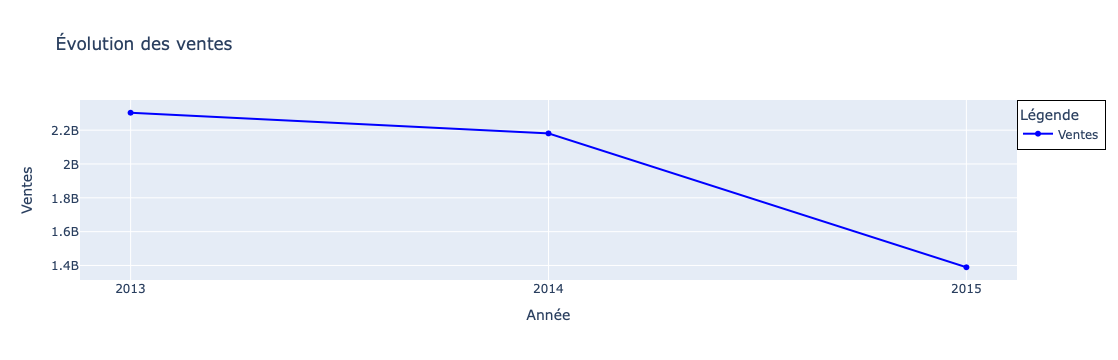

In [146]:
#Visualisation des ventes moyennes avec un graphique en courbes
ventes_moyenne = df_train.groupby(df_train['Date'].dt.year)['Sales'].sum().reset_index()

#Convertir la colonne 'année' en chaîne de caractères pour éviter les demi-années ( 2019,5 etc)
ventes_moyenne['Date'] = ventes_moyenne['Date'].astype(str)

#Tracer le graphique en courbes
fig = px.line(
    ventes_moyenne,
    x='Date',
    y='Sales',
    title='Évolution des ventes',
    labels={'Date': 'Année', 'Sales': 'Ventes'},
    markers=True, 
    template='plotly'
)

fig.update_traces(
    texttemplate='%{text:.2f}',  # Texte formaté avec deux décimales
    textposition='bottom center',   # Position des étiquettes au-dessus des points
    name="Ventes",  
    showlegend=True,
    line=dict(color='blue', width=2) 
)

#Ajout d'une mise en page pour la légende
fig.update_layout(
    legend_title_text="Légende",  
    legend=dict(
        x=1,  
        y=1,     
        xanchor="left",  
        yanchor="top", 
        bgcolor="rgba(255,255,255,0.7)",  
        bordercolor="Black", 
        borderwidth=1
    )
)

#Afficher le graphique
fig.show()

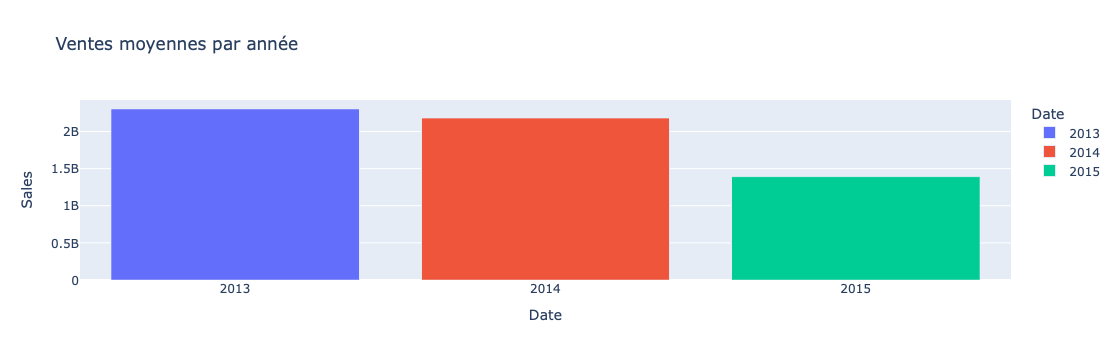

In [148]:
#Visualisation des ventes moyennes par année et les clients par année

px.bar(ventes_moyenne, x='Date', y='Sales', title='Ventes moyennes par année', color='Date')

In [150]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 14 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
 9   année          1017209 non-null  int32         
 10  mois           1017209 non-null  int32         
 11  jour           1017209 non-null  int32         
 12  mois_nom       1017209 non-null  object        
 13  jour_nom       1017209 non-null  object        
dtypes: datetime64[ns](1), int32(3), in

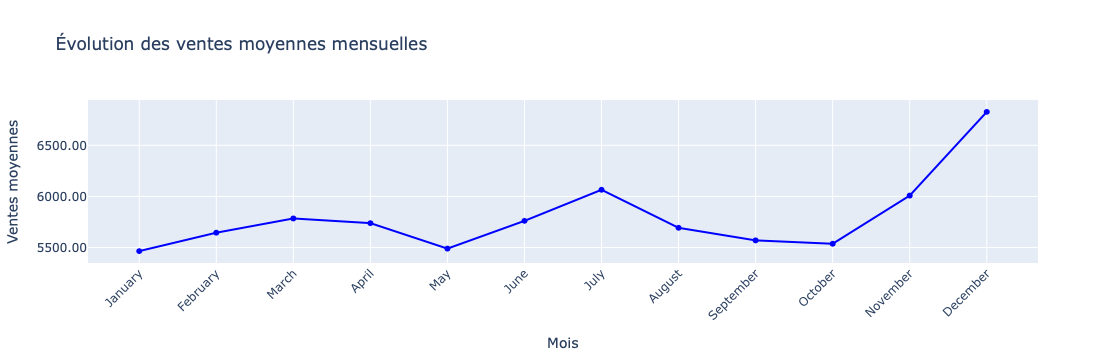

In [299]:
#Visualisation des ventes moyennes mensuelles
# Calculer les ventes moyennes mensuelles
ventes_moyenne_mensuel = df_train.groupby('mois')['Sales'].mean().reset_index()

# Définir l'ordre des mois
ventes_moyenne_mensuel['mois'] = pd.Categorical(
    ventes_moyenne_mensuel['mois'], 
    categories=list(range(1, 13)), 
    ordered=True
)
#La fonction range exclut le deuxième argument. Si je veux inclure tous les mois de 1 à 12, on doit écrire range(1, 13), car 12 serait exclu si on écrit range(1, 12).

#Ajouter des noms de mois pour le graphique et l'ordre
mois_labels = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]
ventes_moyenne_mensuel['mois_nom'] = ventes_moyenne_mensuel['mois'].cat.codes + 1
ventes_moyenne_mensuel['mois_nom'] = ventes_moyenne_mensuel['mois_nom'].map(dict(zip(range(1, 13), mois_labels)))

# Tracer le graphique en courbes
fig = px.line(
    ventes_moyenne_mensuel,
    x='mois_nom',
    y='Sales',
    title='Évolution des ventes moyennes mensuelles',
    labels={'mois_nom': 'Mois', 'Sales': 'Ventes'},
    markers=True,
    template='plotly'
)

# Mise à jour des courbes
fig.update_traces(
    line=dict(color='blue', width=2),
    marker=dict(size=6),
    showlegend=False
)

# Mise à jour de la mise en page
fig.update_layout(
    xaxis_title="Mois",
    yaxis_title="Ventes moyennes",
    xaxis=dict(tickmode='linear', tickangle=-45),
    yaxis=dict(tickformat=".2f"),
    legend=dict(
        x=1, y=1, xanchor='left', yanchor='top',
        bgcolor="rgba(255,255,255,0.7)",
        bordercolor="Black",
        borderwidth=1
    )
)

# Afficher le graphique
fig.show()

In [158]:
#Calcul variation entre janvier et décembre suite au graphique de l'évolution
CA_par_mois = df_train.groupby('mois')['Sales'].sum().reset_index()
CA_mensuel_janvier = CA_par_mois.loc[CA_par_mois['mois'] == 1, 'Sales'].values[0]
CA_mensuel_decembre = CA_par_mois.loc[CA_par_mois['mois'] == 12, 'Sales'].values[0]

#Calcul des variations
variation_absolue_mensuelle = CA_mensuel_janvier - CA_mensuel_decembre
variation_relative_mensuelle = (variation_absolue_mensuelle / CA_mensuel_janvier) * 100

print(f"Les ventes moyennes ont augmenté de {variation_absolue_mensuelle:,.2f}€ ce qui représente une hausse de {variation_relative_mensuelle:,.2f}%.")

Les ventes moyennes ont augmenté de 132,897,571.00€ ce qui représente une hausse de 23.45%.


## 1.6 répartition des clients

In [207]:
#Répartition des clients par types en valeurs absolues
df_store["StoreType"].value_counts()

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

In [209]:
#Répartition des clients par types en pourcentage 
#Normalize pour avoir en taux et *100 pour le pourcentage
df_store["StoreType"].value_counts(normalize=True) * 100

StoreType
a    53.991031
d    31.210762
c    13.273543
b     1.524664
Name: proportion, dtype: float64

In [213]:
# Il y a 54 % de magasins a et 1.52 % seulement de magasins b

Il y a 54 % de magasins a et 1.52 % seulement de magasins b


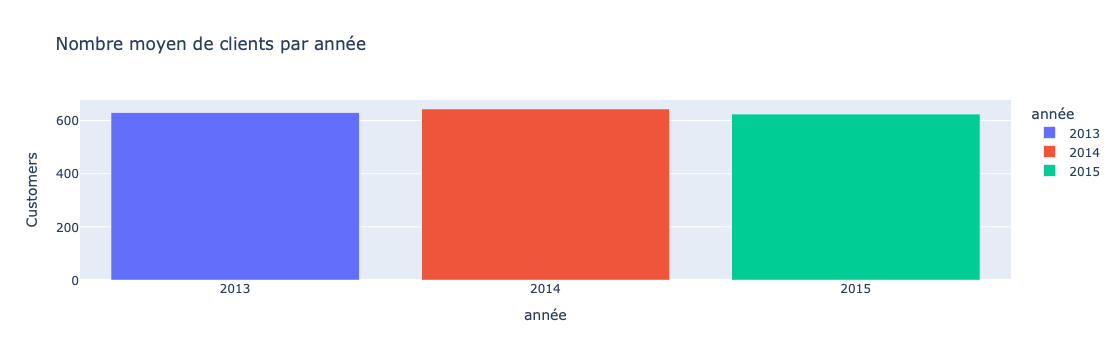

In [176]:
#Visualisation des clients par année et par mois

df_clients = df_train.groupby('année')[['Sales', 'Customers']].mean().reset_index()
#Convertir la colonne 'année' en chaîne de caractères pour éviter les demi-années ( 2019,5 etc)
df_clients['année'] = df_clients['année'].astype(str)

fig = px.bar(df_clients, x='année', y='Customers', title='Nombre moyen de clients par année', color = 'année')
fig.show()

In [182]:
# On peut remarquer une baisse du nombre clients par année entre 2013 et 2015

On peut remarquer une baisse du nombre clients par année entre 2013 et 2015


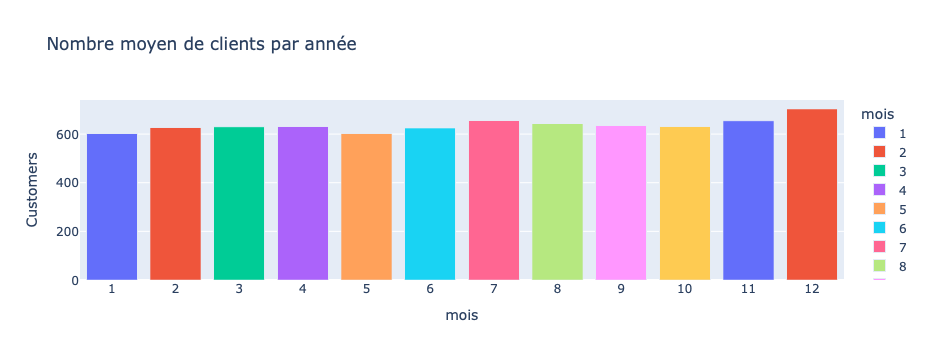

In [180]:
#Visualisation des clients par mois

df_clients_mensuel = df_train.groupby('mois')[['Sales', 'Customers']].mean().reset_index()
#Convertir la colonne 'mois' en chaîne de caractères pour éviter les demi-années ( 2019,5 etc)
df_clients_mensuel['mois'] = df_clients_mensuel['mois'].astype(str)

fig = px.bar(df_clients_mensuel, x='mois', y='Customers', title='Nombre moyen de clients par mois', color = 'mois')
fig.show()

In [319]:
# On peut noter qu'il y a des variations entre les mois avec une augmentation pour la fin d'année (maladies)"

On peut noter qu'il y a des variations entre les mois avec une augmentation pour la fin d'année (maladies)


## 1.7 Fusion des fichiers 

In [491]:
#Fusion des fichiers df_train et df_store
df_combine = pd.merge(df_train, df_store, how='left', on='Store')

#Affichage de la jointure
df_combine

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,année,mois,jour,mois_nom,jour_nom,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,July,Friday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,July,Friday,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"01,04,07,10"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,July,Friday,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"01,04,07,10"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,July,Friday,c,c,620.0,9.0,2009.0,0,NaN,NaN,0
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,July,Friday,a,a,29910.0,4.0,2015.0,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"01,04,07,10"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,c,c,1880.0,4.0,2006.0,0,NaN,NaN,0
1017206,1113,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,c,9260.0,NaN,NaN,0,NaN,NaN,0
1017207,1114,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,c,870.0,NaN,NaN,0,NaN,NaN,0


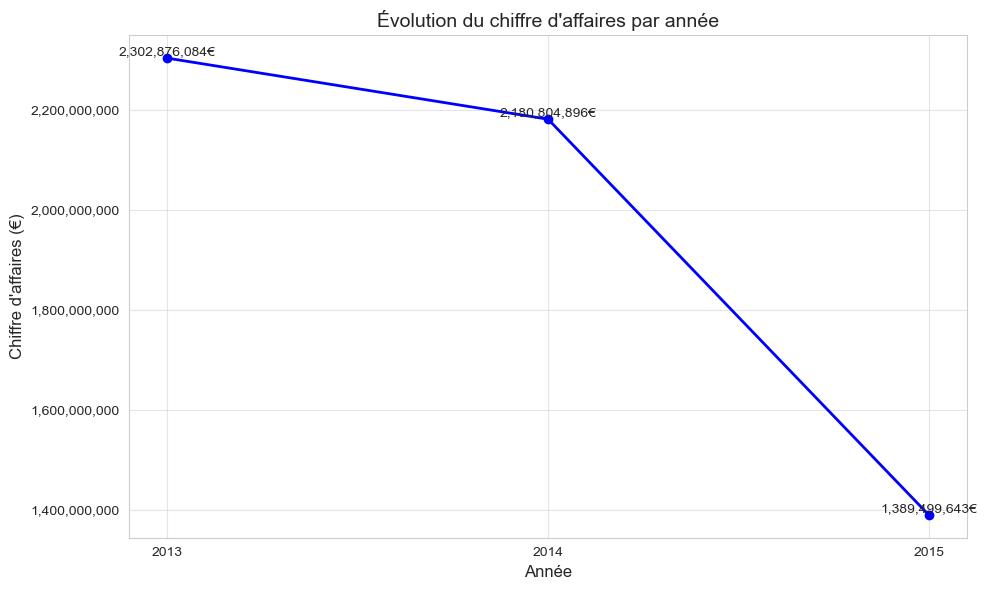

In [265]:
# Graphique ventes par années

#Convertir la colonne 'année' en chaîne de caractères pour éviter les demi-années ( 2019,5 etc)
#Pas de conversion au format datime car les colonnes possèdent déjà l'année (il aurait fallu la date complète)
df_combine['année'] = df_combine['année'].astype(str)

df_merge = df_combine

# Agrégation des ventes par année en utilisant la colonne 'année'
df_merge_resampled = df_merge.groupby('année')['Sales'].sum().reset_index()

# Création du graphique
plt.figure(figsize=(10, 6))  
plt.plot(
    df_merge_resampled['année'],  
    df_merge_resampled['Sales'], 
    marker='o', color='blue', linestyle='-', linewidth=2, markersize=6
)

# Formatage des axes
plt.ticklabel_format(style='plain', axis='y')  # Désactiver la notation scientifique
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))  # Format des milliers

# Titres et étiquettes
plt.title("Évolution du chiffre d'affaires par année", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Chiffre d'affaires (€)", fontsize=12)

# Ajout des valeurs sur chaque point
for year, sales in zip(df_merge_resampled['année'], df_merge_resampled['Sales']):
    plt.text(year, sales, f"{sales:,.0f}€", ha='center', va='bottom', fontsize=10)

# Afficher le graphique
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [284]:
df_combine

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,année,mois,jour,mois_nom,jour_nom,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,July,Friday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,July,Friday,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,July,Friday,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,July,Friday,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,July,Friday,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


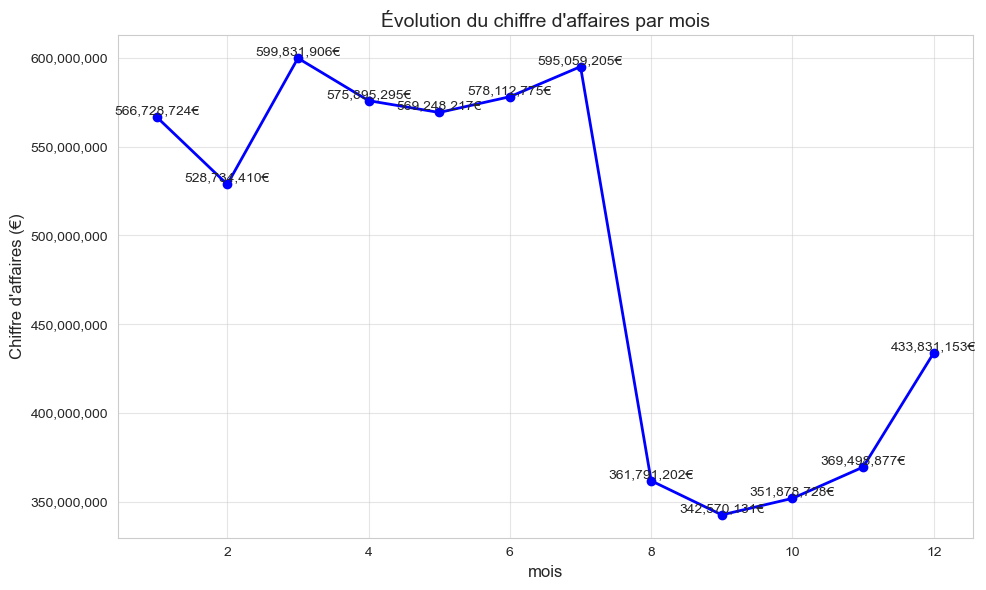

In [276]:
# Graphique ventes par mois
#Convertir la colonne 'année' en chaîne de caractères pour éviter les demi-années ( 2019,5 etc)
#Pas de conversion au format datime car les colonnes possèdent déjà l'année (il aurait fallu la date complète)
#df_combine['année'] = df_combine['année'].astype(str)

#df_merge = df_combine

# Agrégation des ventes par année en utilisant la colonne 'année'
df_merge_resampled = df_merge.groupby('mois')['Sales'].sum().reset_index()

# Création du graphique
plt.figure(figsize=(10, 6))  
plt.plot(
    df_merge_resampled['mois'],  
    df_merge_resampled['Sales'], 
    marker='o', color='blue', linestyle='-', linewidth=2, markersize=6
)

# Formatage des axes
plt.ticklabel_format(style='plain', axis='y')  # Désactiver la notation scientifique
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))  # Format des milliers

# Titres et étiquettes
plt.title("Évolution du chiffre d'affaires par mois", fontsize=14)
plt.xlabel("mois", fontsize=12)
plt.ylabel("Chiffre d'affaires (€)", fontsize=12)

# Ajout des valeurs sur chaque point
for mois, sales in zip(df_merge_resampled['mois'], df_merge_resampled['Sales']):
    plt.text(mois, sales, f"{sales:,.0f}€", ha='center', va='bottom', fontsize=10)

# Afficher le graphique
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [296]:
#On peut voir également une évolution à la baisse du chiffre d'affaires mensuel
CA_par_mois = df_combine.groupby('mois')['Sales'].sum().reset_index()
CA_mensuel_janvier = CA_par_mois.loc[CA_par_mois['mois'] == 1, 'Sales'].values[0]
CA_mensuel_decembre = CA_par_mois.loc[CA_par_mois['mois'] == 12, 'Sales'].values[0]

#Calcul des variations
variation_absolue_mensuelle = CA_mensuel_janvier - CA_mensuel_decembre
variation_relative_mensuelle = (variation_absolue_mensuelle / CA_mensuel_janvier) * 100

print(f"Le chiffre d\'affaires a diminué de {variation_absolue_mensuelle:,.2f}€ ce qui représente une baisse de {variation_relative_mensuelle:,.2f}%.")

Le chiffre d'affaires a diminué de 132,897,571.00€ ce qui représente une baisse de 23.45%.


In [301]:
# Le graphique permet de visualiser l'évolution sur 12 mois du CA
# On peut voir qu'il y une forte période allant de mars à juillet"
# Et une très forte baisse entre juillet et août"
# Je remarque en même temps le paradoxe de voir que les ventes moyennes et chiffre mensuel évolue dans le sens inverse
# Cela traduit que les ventes sont en moyennes plus fortes en décembre mais que au total le mois de janvier est plus fort

Le graphique permet de visualiser l'évolution sur 12 mois du CA
On peut voir qu'il y une forte période allant de mars à juillet
Et une très forte baisse entre juillet et août
Je remarque en même temps le paradoxe de voir que les ventes moyennes et chiffre mensuel évolue dans le sens inverse
Cela traduit que les ventes sont en moyennes plus fortes en décembre mais que au total le mois de janvier est plus fort


In [303]:
df_combine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 23 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   année                      1017209 non-null  object        
 10  mois                       1017209 non-null  int32         
 11  jour                       1017209 no

# 2. Caractérisez les différentes typologies de magasin

## 2.1 Répartition des différents magasins

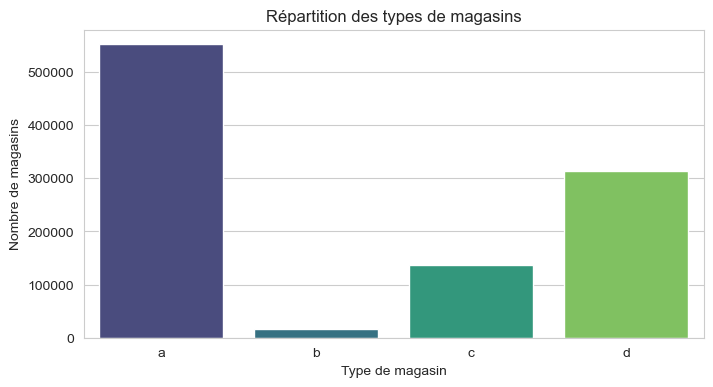

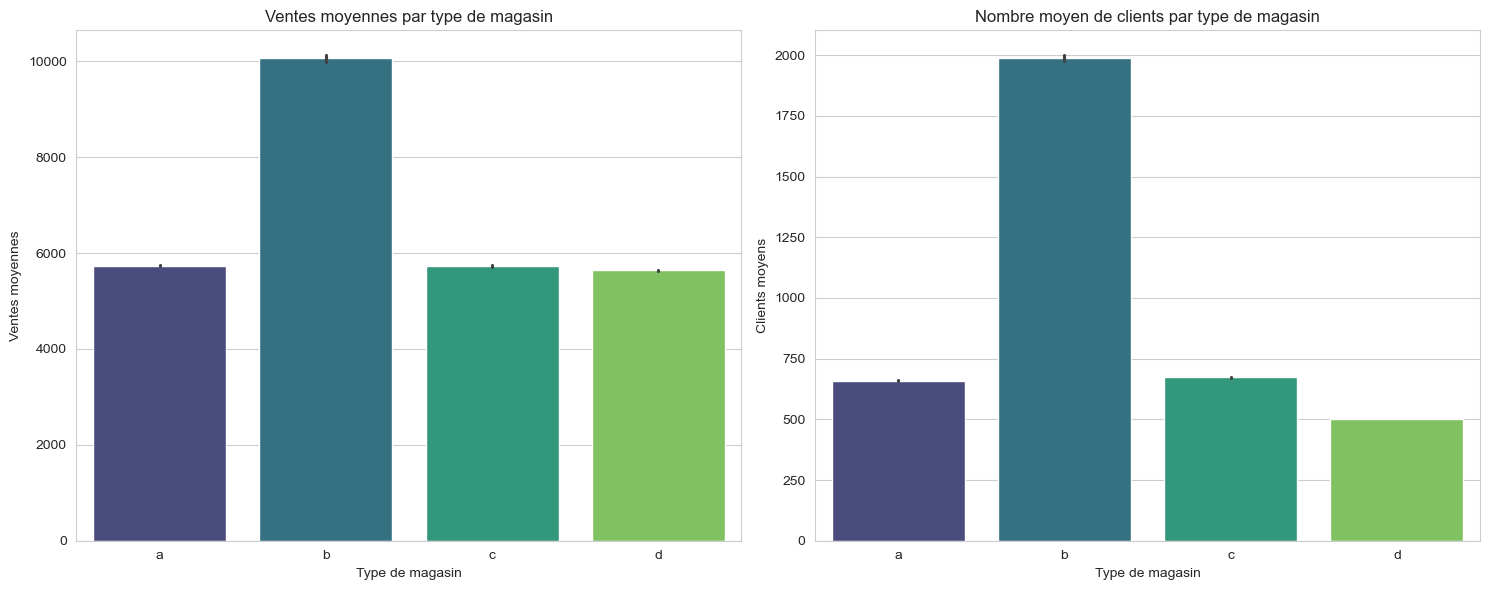

In [262]:
#Visualisation avec 3 graphiques pour les types de magasins, les ventes et les clients avec storetype

# Configuration fond blanc avec grille
sns.set_style("whitegrid")

# Graphique 1 : Répartition des types de magasins
plt.figure(figsize=(8, 4))
sns.countplot(x='StoreType', data=df_combine, order=['a', 'b', 'c', 'd'], palette='viridis')
plt.title("Répartition des types de magasins")
plt.xlabel("Type de magasin")
plt.ylabel("Nombre de magasins")
plt.show()

# Graphiques 2 et 3 : Ventes moyennes et clients moyens par type de magasin
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 2 : Ventes moyennes par type de magasin
sns.barplot(x='StoreType', y='Sales', data=df_combine, order=['a', 'b', 'c', 'd'], ax=axis1, palette='viridis')
axis1.set_title("Ventes moyennes par type de magasin")
axis1.set_xlabel("Type de magasin")
axis1.set_ylabel("Ventes moyennes")

# Graphique 3 : Clients moyens par type de magasin
sns.barplot(x='StoreType', y='Customers', data=df_combine, order=['a', 'b', 'c', 'd'], ax=axis2, palette='viridis')
axis2.set_title("Nombre moyen de clients par type de magasin")
axis2.set_xlabel("Type de magasin")
axis2.set_ylabel("Clients moyens")

# Ajustement de la mise en page
plt.tight_layout()
plt.show()

In [263]:
#Afficher les différentes valeurs de la colonne Assortment
df_combine['Assortment'].unique()

array(['a', 'c', 'b'], dtype=object)

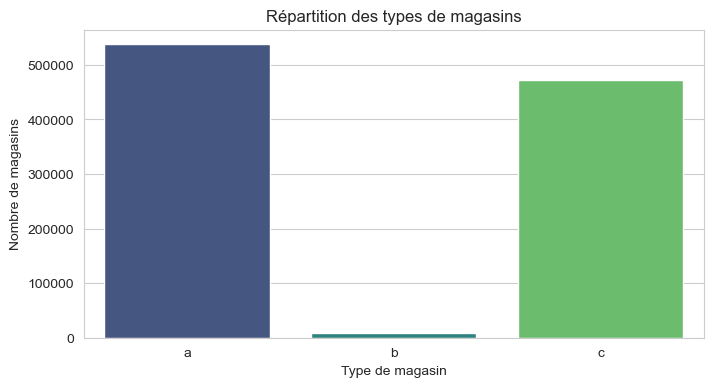

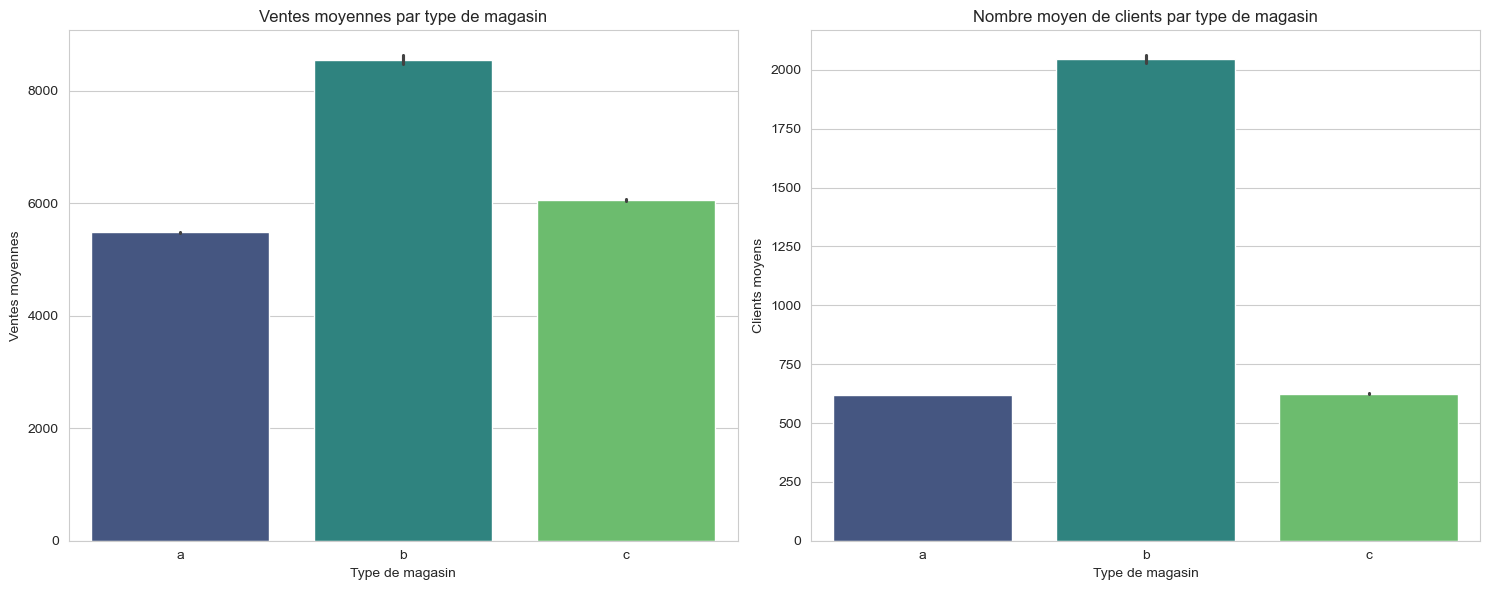

In [264]:
#Visualisation avec 3 graphiques pour les types de magasins, les ventes et les clients avec assortment

# Configuration fond blanc avec grille
sns.set_style("whitegrid")

# Graphique 1 : Répartition des types de magasins
plt.figure(figsize=(8, 4))
sns.countplot(x='Assortment', data=df_combine, order=['a', 'b', 'c'], palette='viridis')
plt.title("Répartition des types de magasins")
plt.xlabel("Type de magasin")
plt.ylabel("Nombre de magasins")
plt.show()

# Graphiques 2 et 3 : Ventes moyennes et clients moyens par type de magasin
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 2 : Ventes moyennes par type de magasin
sns.barplot(x='Assortment', y='Sales', data=df_combine, order=['a', 'b', 'c'], ax=axis1, palette='viridis')
axis1.set_title("Ventes moyennes par type de magasin")
axis1.set_xlabel("Type de magasin")
axis1.set_ylabel("Ventes moyennes")

# Graphique 3 : Clients moyens par type de magasin
sns.barplot(x='Assortment', y='Customers', data=df_combine, order=['a', 'b', 'c'], ax=axis2, palette='viridis')
axis2.set_title("Nombre moyen de clients par type de magasin")
axis2.set_xlabel("Type de magasin")
axis2.set_ylabel("Clients moyens")

# Ajustement de la mise en page
plt.tight_layout()
plt.show()

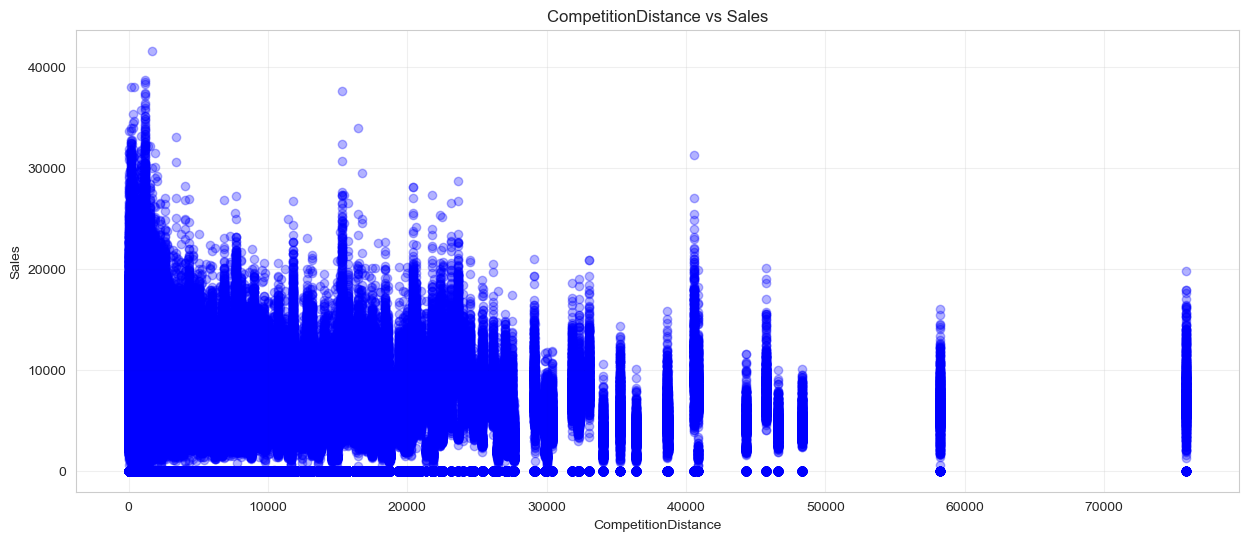

In [343]:
#Visualisation et analyse des magasins vs concurrence

# Remplissage des NaN
df_combine["CompetitionDistance"].fillna(df_combine["CompetitionDistance"].median(), inplace=True)
# Remplissage par la médiane pour éviter que des possibles outliers influencent les données

# Nuage de points : CompetitionDistance vs Sales
plt.figure(figsize=(15, 6))
plt.scatter(df_combine["CompetitionDistance"], df_combine["Sales"], alpha=0.3, color='blue')
plt.title("CompetitionDistance vs Sales")
plt.xlabel("CompetitionDistance")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

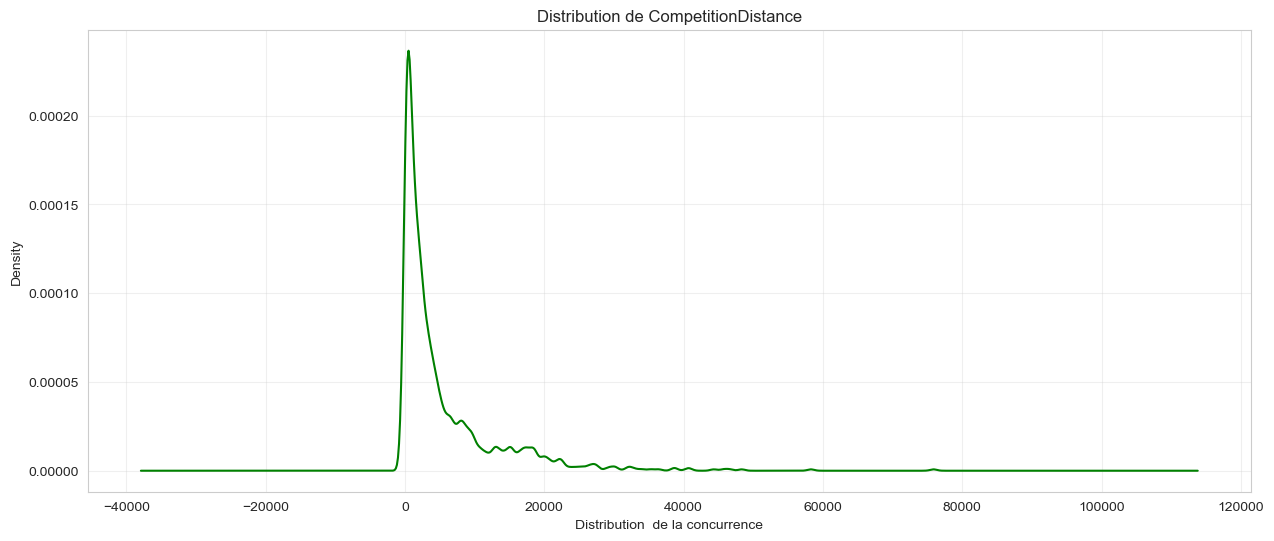

In [349]:
# Graphique de densité : Distribution de 'CompetitionDistance'

plt.figure(figsize=(15, 6))
df_combine["CompetitionDistance"].plot(kind='kde', color='green')
plt.title("Distribution de CompetitionDistance")
plt.xlabel("Distribution  de la concurrence")
plt.grid(alpha=0.3)
plt.show()

In [351]:
#On peut voir avce les deux graphiques que les magasins qui ont beaucoup de concurrents proche d'eux font plus de CA
#A l'inverse, moins ils ont de concurrence, mois ils font du CA
#Cela peut s'expliquer par le fait que le flux client est plus important
#Mais cela peut aussi s'expliquer par l'implentation incorrect des magasins qui les rendent peu accessible

On peut voir avce les deux graphiques que les magasins qui ont beaucoup de concurrents proche d'eux font plus de CA
A l'inverse, moins ils ont de concurrence, mois ils font du CA
Cela peut s'expliquer par le fait que le flux client est plus important
Mais cela peut aussi s'expliquer par l'implentation incorrect des magasins qui les rendent peu accessible


## 2.2 Corrélation

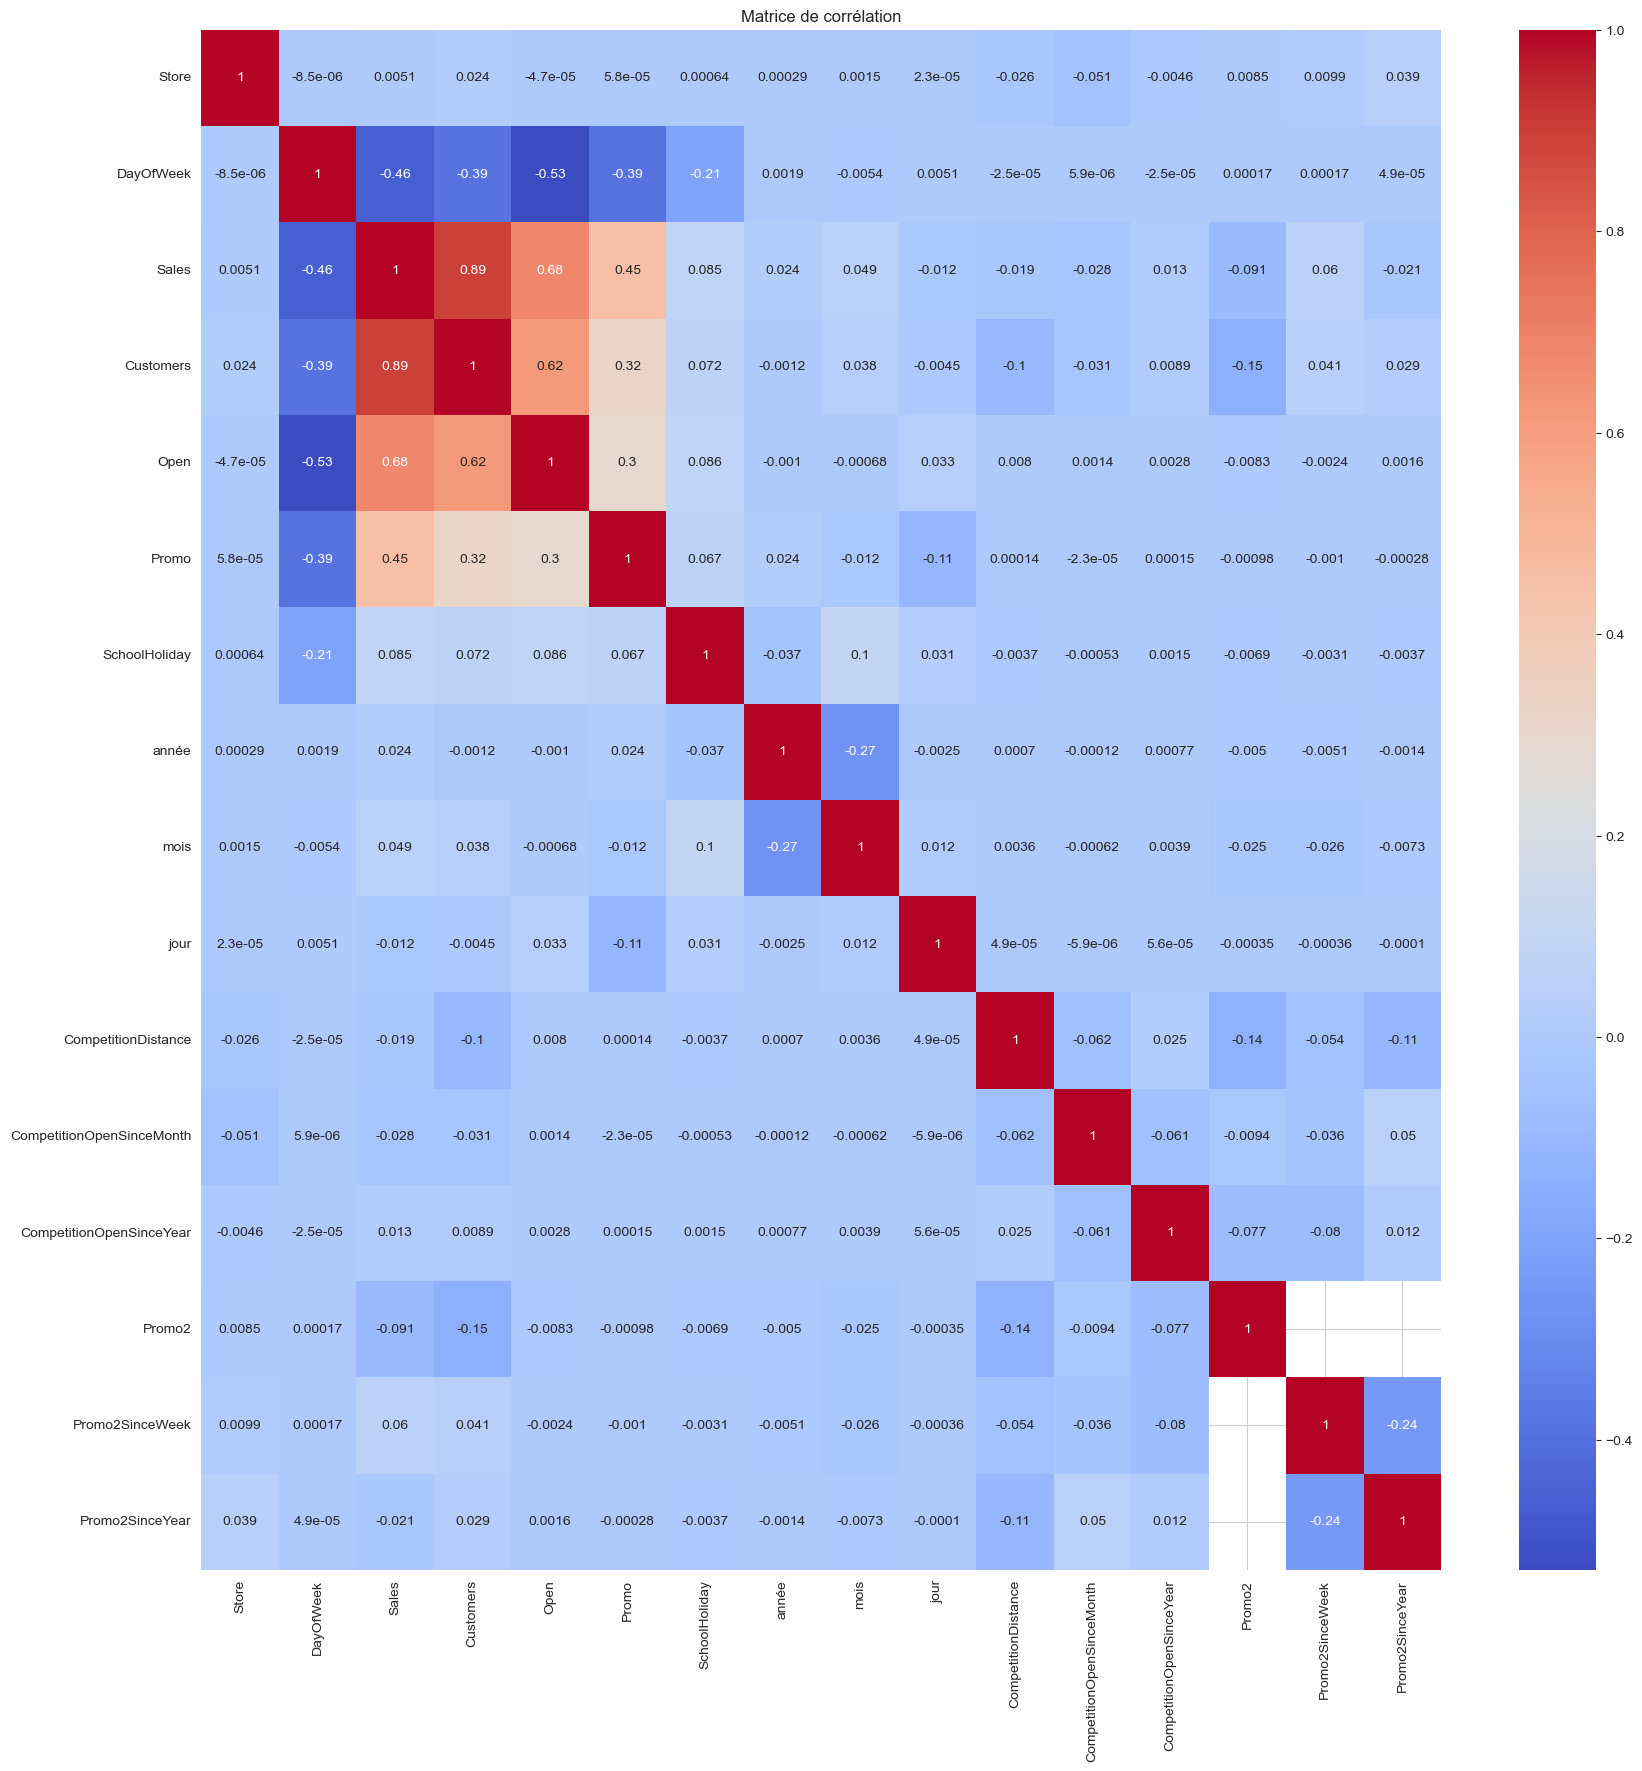

In [355]:
# Corrélation entre les ventes et les magasins
df_sales_train_combine = pd.merge(df_train, df_store, how = 'inner', on = 'Store')

# Sélection des colonnes numériques uniquement car message d'erreur à causes des colonnes storetype etc

correlations = df_sales_train_combine.select_dtypes(include=['number']).corr()

# Création de la heatmap

f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(correlations, annot=True, cmap='coolwarm') # annot pour afficher les coefficients de corrélation sur chaque cellule
plt.title('Matrice de corrélation')

# Affichage du heatmap
plt.show()

# Problème avec les colonnes avec les chaînes de caractères résolu avec l'inclusion uniquement des données numériques

In [375]:
#On peut observer que le nombre de clients et le CA est fortement corrélé 0.89
#On peut s'intérroger sur pourquoi la corrélation entre open et customers n'est pas plus forte
#J'observe également qu'il y a une faible corrélation (proche de 0) entre les vacances scolaires et les ventes
#La corrélation entre les jours de la semaine et l'ouverture des magasins s'expliquent par le fait que tous les magasins n'ouvrent pas 
#Les dimanches, jours fériés etc
#Il y a également peu de corrélation entre la distance entre les concurrents et le nombre moyen de clients et le CA

On peut observer que le nombre de clients et le CA est fortement corrélé 0.89
On peut s'intérroger sur pourquoi la corrélation entre open et customers n'est pas plus forte
J'observe également qu'il y a une faible corrélation (proche de 0) entre les vacances scolaires et les ventes
La corrélation entre les jours de la semaine et l'ouverture des magasins s'expliquent par le fait que tous les magasins n'ouvrent pas 
Les dimanches, jours fériés etc
Il y a également peu de corrélation entre la distance entre les concurrents et le nombre moyen de clients et le CA


In [357]:
# Vérification de l'analyse ci-dessus
df_sales_train_combine.groupby('DayOfWeek')['Open'].mean()

DayOfWeek
1    0.950459
2    0.988309
3    0.974400
4    0.923199
5    0.950598
6    0.995357
7    0.024826
Name: Open, dtype: float64

In [361]:
#L'analyse confirme bien que peu de magasin sont ouvert le dimanche et que certains ferment le jeudi

L'analyse confirme bien que peu de magasin sont ouvert le dimanche et que certains ferment le jeudi


In [369]:
# Autres commentaires

#La corrélation entre les promotions et les ventes sont de 0.45. Ce qui signifie que les promotions influencent
#Les ventes de manière modérées
#Il faudrait également analyser les promotions pour déterminer si elles ont oui ou non elles ont été efficaces
#En conclusion, les promotions aident à développer le chiffre mais sans promotion le CA continuera de se développer

La corrélation entre les promotions et les ventes sont de 0.45. Ce qui signifie que les promotions influencent
les ventes de manière modérées
Il faudrait également analyser les promotions pour déterminer si elles ont oui ou non elles ont été efficaces
En conclusion, les promotions aident à développer le chiffre mais sans promotion le CA continuera de se développer


## 2. Régression linéaire

In [493]:
# Afficher les 5 premières et dernières lignes du nouveau dataframe ( variable dépendantess )
Y_train = df_combine.groupby('Store')[["Sales"]].mean()

# Afficher le chiffre d'affaire moyen quotidien par magasin
Y_train

,Sales
Store,
1,3945.704883
2,4122.991507
3,5741.253715
4,8021.769639
5,3867.110403
...,...
1111,4342.968153
1112,8465.280255
1113,5516.180467


In [495]:
# Nombre de client quotidien moyen par magasin ( variable indépendantes )
X_train = df_combine.groupby('Store')[["Customers"]].mean()

# Afficher le nombre de client moyen quotidien par magasin
X_train

,Customers
Store,
1,467.646497
2,486.045648
3,620.286624
4,1100.057325
5,444.360934
...,...
1111,373.548832
1112,693.498938
1113,596.763270


In [497]:
#Import de la classe Linear Regression 
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X_train, Y_train)

In [499]:
#Evaluation des performances du modèle de régression linéaire
lr.score(X_train,Y_train)

0.7023112769496345

In [371]:
#Commentaire sur la performance du modèle

# 70 % de la variance Y est expliquée par les caractéristiques X = Caractéristiques X = Clients - pour prédire ou expliquer
# 30 % reste inexpliquée
# Ce qui signifie concrètement que 70% des ventes sont expliquées par le nombre moyen de clients
# Et ce qui signifie que les 30 % restant peut être lié aux promotions, à la concurrence aux types de magasin etc

70 % de la variance Y est expliquée par les caractéristiques X
30 % reste inexpliquée
Ce qui signifie concrètement que 70% des ventes sont expliquées par le nombre moyen de clients
Et ce qui signifie que les 30 % restant peut être lié aux promotions, à la concurrence aux types de magasin etc


## 3. K-means

In [501]:
# Création DataFrame pour la future analyse 

df_merge = df_combine.groupby(['Store'])[['Open', 'Sales', 'Customers', 'CompetitionDistance', 'Promo', 'Promo2', 'SchoolHoliday']].mean().reset_index()
df_merge

# Note : Suppression de stateholiday dans ce dataframe car objet

,Store,Open,Sales,Customers,CompetitionDistance,Promo,Promo2,SchoolHoliday
0,1,0.829087,3945.704883,467.646497,1270.0,0.382166,0.0,0.204883
1,2,0.832272,4122.991507,486.045648,570.0,0.382166,1.0,0.177282
2,3,0.826964,5741.253715,620.286624,14130.0,0.382166,1.0,0.180467
3,4,0.832272,8021.769639,1100.057325,620.0,0.382166,0.0,0.183652
4,5,0.826964,3867.110403,444.360934,29910.0,0.382166,0.0,0.182590
...,...,...,...,...,...,...,...,...
1110,1111,0.826964,4342.968153,373.548832,1900.0,0.382166,1.0,0.180467
1111,1112,0.826964,8465.280255,693.498938,1880.0,0.382166,0.0,0.180467
1112,1113,0.832272,5516.180467,596.763270,9260.0,0.382166,0.0,0.168790
1113,1114,0.832272,17200.196391,2664.057325,870.0,0.382166,0.0,0.179406


In [503]:
df_merge.column()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                1115 non-null   int64  
 1   Open                 1115 non-null   float64
 2   Sales                1115 non-null   float64
 3   Customers            1115 non-null   float64
 4   CompetitionDistance  1112 non-null   float64
 5   Promo                1115 non-null   float64
 6   Promo2               1115 non-null   float64
 7   SchoolHoliday        1115 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 69.8 KB


In [505]:
Kmeans_train = df_merge[['Customers', 'CompetitionDistance']]

In [507]:
# Chargement des librairies graphiques
sns.set()

In [508]:
# Import de la librairie

from sklearn.preprocessing import StandardScaler

In [511]:
# Normalisation des données

std=StandardScaler()
data = Kmeans_train
std_data=std.fit_transform(data)
std_data=pd.DataFrame(std_data, columns = 'scaled_'+ data.columns) # Nom des colonnes

# Affichage des informations
std_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   scaled_Customers            1115 non-null   float64
 1   scaled_CompetitionDistance  1112 non-null   float64
dtypes: float64(2)
memory usage: 17.6 KB


In [513]:
# Remplissage des valeurs manquantes
# K-means ne tolère pas les NaN

std_data = std_data.fillna(0)

In [515]:
# Affichage 

std_data

,scaled_Customers,scaled_CompetitionDistance
0,-0.508260,-0.539823
1,-0.450482,-0.631211
2,-0.028928,1.139087
3,1.477683,-0.624683
4,-0.581383,3.199213
...,...,...
1110,-0.803753,-0.457575
1111,0.200979,-0.460186
1112,-0.102798,0.503294
1113,6.389073,-0.592045


In [517]:
# Import

from sklearn.cluster import KMeans

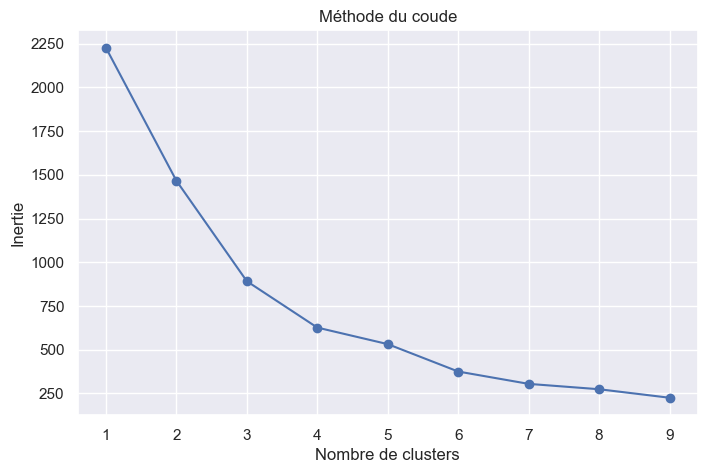

In [519]:
# Déterminer le nombre de cluster

inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42) #randon : fixe la graine aléatoire pour garantir la reproductivité des résultats
    km.fit(std_data)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertias, marker='o')
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

In [395]:
# Grâce à la méthode du coude, nous pouvons déterminer déterminer qu'il y a 4 clusters

Grâce à la méthode du coude, nous pouvons déterminer déterminer qu'il y a 4 clusters


## 4. Clusters

In [521]:
# Déterminer le nombre de clusters

km = KMeans(n_clusters=4, random_state=42)
km.fit(std_data)

KMeans(n_clusters=4, random_state=42)

In [523]:
# Evaluation de la qualité de mon clusters

KMeans(n_clusters=4, random_state=42).fit(std_data).inertia_

626.3854453388108

In [525]:
# Liste des clusters

km.labels_

array([0, 0, 1, ..., 0, 2, 0], dtype=int32)

In [ ]:
# Note : cluster 0 n'est pas supérieur au cluster 1 = "pas une valeur mais un id"

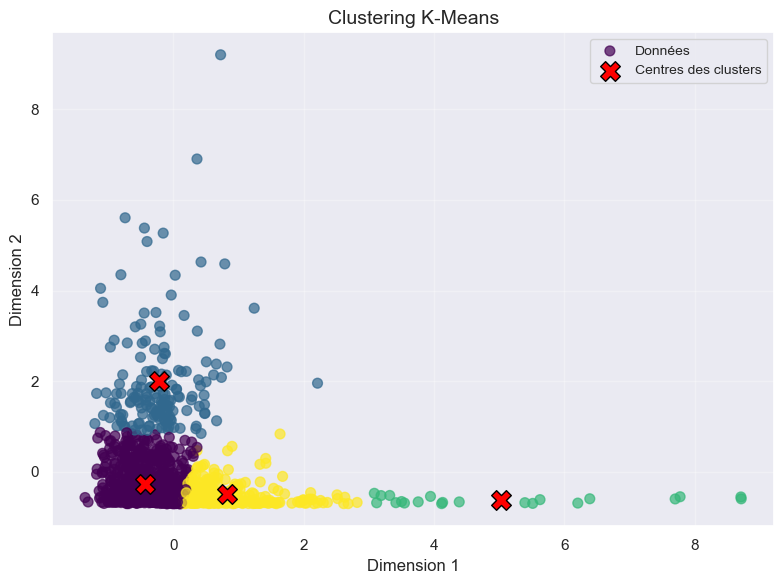

In [529]:
plt.figure(figsize=(8, 6))

# Points des données avec leurs clusters (couleurs)
plt.scatter(std_data.iloc[:, 0], std_data.iloc[:, 1], c=km.labels_, cmap='viridis', s=50, alpha=0.7, label='Données')

# Centres des clusters
plt.scatter(
    km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], 
    c='red', marker='X', s=200, edgecolor='black', label='Centres des clusters'
)

# Ajout des titres et étiquettes
plt.title("Clustering K-Means", fontsize=14)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)

# Ajout de la légende
plt.legend(loc='best', fontsize=10)

# Ajout d'une grille légère
plt.grid(alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

In [539]:
# A partir de la, j'aimerais attribuer les clusters au bon magasin et connaître le nombre de magasin dans chaque cluster")

A partir de la, j'aimerais attribuer les clusters au bon magasin et connaître le nombre de magasin dans chaque cluster


In [541]:
# Ajouter une colonne "cluster" avec les labels générés par KMeans

df_merge['cluster'] = km.labels_

In [543]:
# Visualisation du dataframe avec la nouvelle colonne
df_merge

,Store,Open,Sales,Customers,CompetitionDistance,Promo,Promo2,SchoolHoliday,cluster
0,1,0.829087,3945.704883,467.646497,1270.0,0.382166,0.0,0.204883,0
1,2,0.832272,4122.991507,486.045648,570.0,0.382166,1.0,0.177282,0
2,3,0.826964,5741.253715,620.286624,14130.0,0.382166,1.0,0.180467,1
3,4,0.832272,8021.769639,1100.057325,620.0,0.382166,0.0,0.183652,3
4,5,0.826964,3867.110403,444.360934,29910.0,0.382166,0.0,0.182590,1
...,...,...,...,...,...,...,...,...,...
1110,1111,0.826964,4342.968153,373.548832,1900.0,0.382166,1.0,0.180467,0
1111,1112,0.826964,8465.280255,693.498938,1880.0,0.382166,0.0,0.180467,3
1112,1113,0.832272,5516.180467,596.763270,9260.0,0.382166,0.0,0.168790,0
1113,1114,0.832272,17200.196391,2664.057325,870.0,0.382166,0.0,0.179406,2


In [545]:
# Compter le nombre de magasins par cluster
nombre_magasins_par_cluster = df_merge['cluster'].value_counts().sort_index()

print("Nombre de magasins par cluster :")
print(nombre_magasins_par_cluster)

Nombre de magasins par cluster :
cluster
0    673
1    160
2     21
3    261
Name: count, dtype: int64


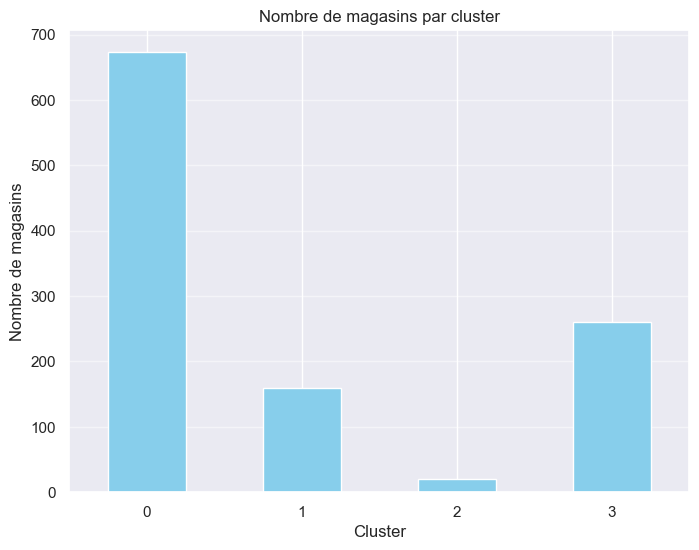

In [547]:
# Graphique des magasins par cluster

nombre_magasins_par_cluster.plot(kind='bar', color='skyblue', figsize=(8, 6))
plt.title('Nombre de magasins par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de magasins')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)

# Affichage du graphique 
plt.show()

# 3. Construisez un modèle de prévision des ventes

In [549]:
df_combine

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,année,mois,jour,mois_nom,jour_nom,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,July,Friday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,July,Friday,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"01,04,07,10"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,July,Friday,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"01,04,07,10"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,July,Friday,c,c,620.0,9.0,2009.0,0,NaN,NaN,0
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,July,Friday,a,a,29910.0,4.0,2015.0,0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"01,04,07,10"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,c,c,1880.0,4.0,2006.0,0,NaN,NaN,0
1017206,1113,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,c,9260.0,NaN,NaN,0,NaN,NaN,0
1017207,1114,2,2013-01-01,0,0,0,0,a,1,2013,1,1,January,Tuesday,a,c,870.0,NaN,NaN,0,NaN,NaN,0


In [551]:
# Prévision avec le dataframe
df_prev = df_combine

# On commence par chercher les magasins ouvert

df_prev = df_prev[df_prev['Open'] == 1]

# Trier les données par date
df_prev = df_prev.sort_values(by=['Store', 'Date'])

# Calculer la moyenne mobile sur une période donnée (15 jours)
window_size = 15
df_prev['moyenne_mobile'] = df_prev.groupby('Store')['Sales'].rolling(window=window_size).mean().reset_index(level=0, drop=True)
df_prev

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,année,mois,jour,mois_nom,jour_nom,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,moyenne_mobile
1014980,1,3,2013-01-02,5530,668,1,0,0,1,2013,1,2,January,Wednesday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0,NaN
1013865,1,4,2013-01-03,4327,578,1,0,0,1,2013,1,3,January,Thursday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0,NaN
1012750,1,5,2013-01-04,4486,619,1,0,0,1,2013,1,4,January,Friday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0,NaN
1011635,1,6,2013-01-05,4997,635,1,0,0,1,2013,1,5,January,Saturday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0,NaN
1009405,1,1,2013-01-07,7176,785,1,1,0,1,2013,1,7,January,Monday,c,a,1270.0,9.0,2008.0,0,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1115,1,2015-07-27,10712,608,1,1,0,1,2015,7,27,July,Monday,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"03,06,09,12",7000.600000
4459,1115,2,2015-07-28,8093,500,1,1,0,1,2015,7,28,July,Tuesday,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"03,06,09,12",7150.533333
3344,1115,3,2015-07-29,7661,473,1,1,0,1,2015,7,29,July,Wednesday,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"03,06,09,12",7183.666667
2229,1115,4,2015-07-30,8405,502,1,1,0,1,2015,7,30,July,Thursday,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"03,06,09,12",7037.466667


In [555]:
# Affichage pour vérifier que le calcul moyenne mobile reparte bien à 0 à chaque magasin:

print(df_prev.head(10)) # Plus simple pour la visualisation

         Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
1014980      1          3 2013-01-02   5530        668     1      0   
1013865      1          4 2013-01-03   4327        578     1      0   
1012750      1          5 2013-01-04   4486        619     1      0   
1011635      1          6 2013-01-05   4997        635     1      0   
1009405      1          1 2013-01-07   7176        785     1      1   
1008290      1          2 2013-01-08   5580        654     1      1   
1007175      1          3 2013-01-09   5471        626     1      1   
1006060      1          4 2013-01-10   4892        615     1      1   
1004945      1          5 2013-01-11   4881        592     1      1   
1003830      1          6 2013-01-12   4952        646     1      0   

        StateHoliday  SchoolHoliday  année  mois  jour mois_nom   jour_nom  \
1014980            0              1   2013     1     2  January  Wednesday   
1013865            0              1   2013     1     3  Januar

In [557]:
# Affichage de 20 quantités car n'est pas assez + print permet de mieux voir mais il y a trop de colonnes

print(df_prev[df_prev['Store'] == 1][['Store', 'Date', 'Sales', 'Customers', 'moyenne_mobile']].head(20))

         Store       Date  Sales  Customers  moyenne_mobile
1014980      1 2013-01-02   5530        668             NaN
1013865      1 2013-01-03   4327        578             NaN
1012750      1 2013-01-04   4486        619             NaN
1011635      1 2013-01-05   4997        635             NaN
1009405      1 2013-01-07   7176        785             NaN
1008290      1 2013-01-08   5580        654             NaN
1007175      1 2013-01-09   5471        626             NaN
1006060      1 2013-01-10   4892        615             NaN
1004945      1 2013-01-11   4881        592             NaN
1003830      1 2013-01-12   4952        646             NaN
1001600      1 2013-01-14   4717        616             NaN
1000485      1 2013-01-15   3900        512             NaN
999370       1 2013-01-16   4008        530             NaN
998255       1 2013-01-17   4044        503             NaN
997140       1 2013-01-18   4127        568     4872.533333
996025       1 2013-01-19   5182        

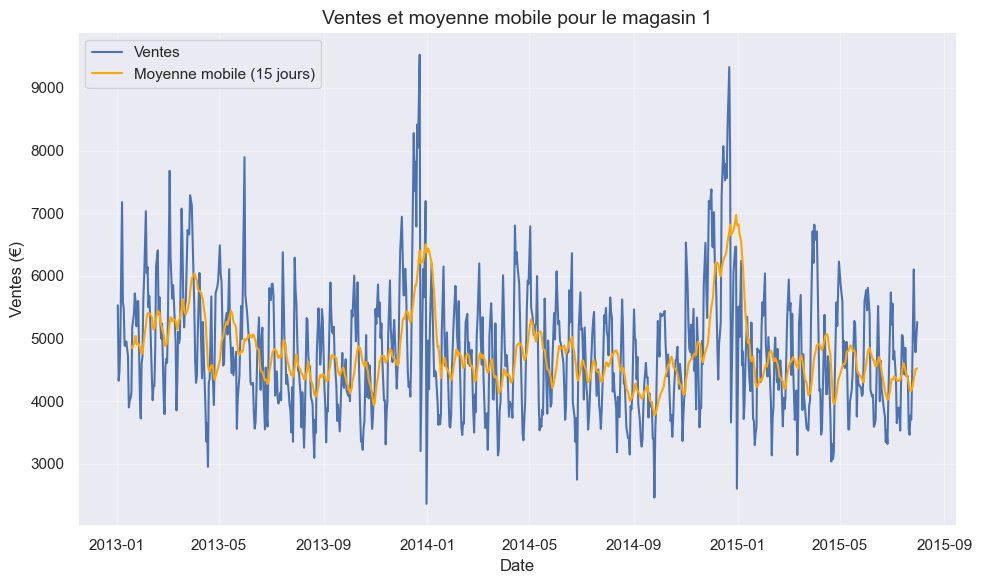

In [561]:
# Visualition de la moyenne mobile pour un magasin donnée : store 1

store_id = 1
store_data = df_prev[df_prev['Store'] == store_id]

# Création de la figure
plt.figure(figsize=(10, 6))

# Graphique des ventes
plt.plot(store_data['Date'], store_data['Sales'], label='Ventes')

# Graphique de la moyenne mobile
plt.plot(store_data['Date'], store_data['moyenne_mobile'], label='Moyenne mobile (15 jours)', color='orange')

# Ajout des légendes
plt.legend()

# Titres
plt.title(f"Ventes et moyenne mobile pour le magasin {store_id}", fontsize=14)
plt.xlabel("Date", fontsize=12)  
plt.ylabel("Ventes (€)", fontsize=12) 

# Amélioration du style des axes
plt.grid(alpha=0.3)

# Affichage du graphique
plt.tight_layout()
plt.show()

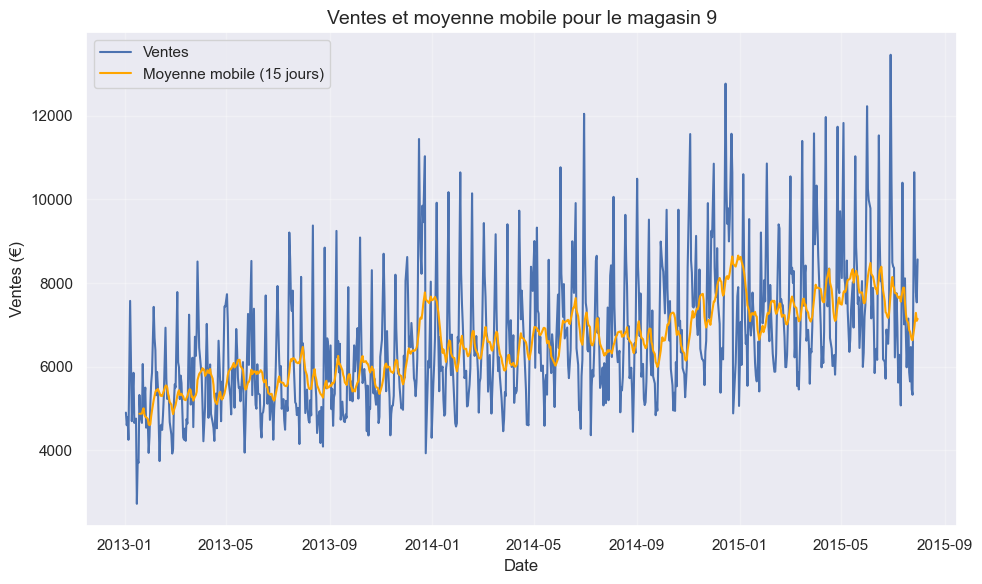

In [575]:
# Visualition de la moyenne mobile pur un magasin donnée : store 9

store_id = 9
store_data = df_prev[df_prev['Store'] == store_id]

# Création de la figure
plt.figure(figsize=(10, 6))

# Graphique des ventes
plt.plot(store_data['Date'], store_data['Sales'], label='Ventes')

# Graphique de la moyenne mobile
plt.plot(store_data['Date'], store_data['moyenne_mobile'], label='Moyenne mobile (15 jours)', color='orange')

# Ajout des légendes
plt.legend()

# Titres
plt.title(f"Ventes et moyenne mobile pour le magasin {store_id}", fontsize=14)
plt.xlabel("Date", fontsize=12)  
plt.ylabel("Ventes (€)", fontsize=12) 

# Amélioration du style des axes
plt.grid(alpha=0.3)

# Affichage du graphique
plt.tight_layout()
plt.show()

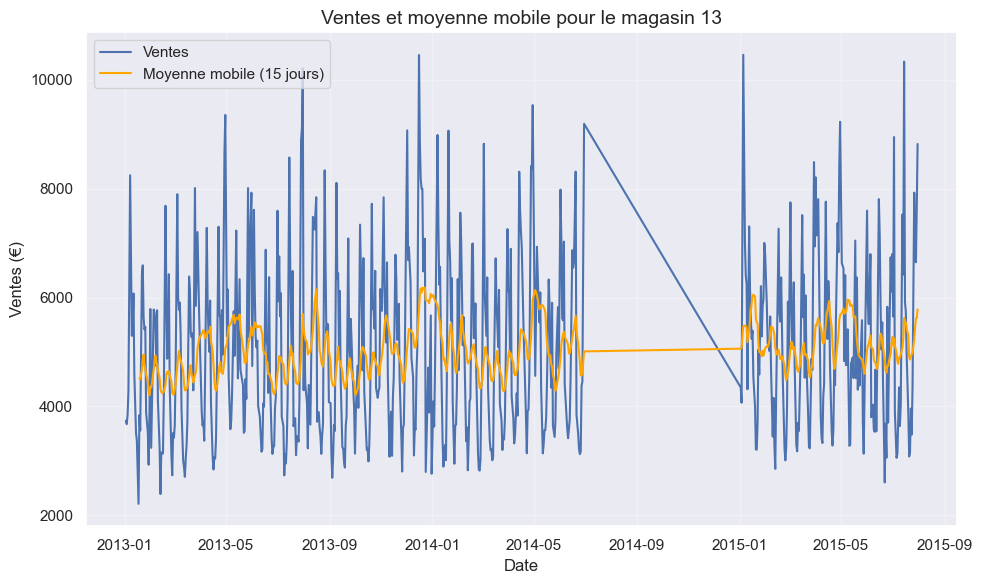

In [577]:
# Visualition de la moyenne mobile pur un magasin donnée : store 13

store_id = 13
store_data = df_prev[df_prev['Store'] == store_id]

# Création de la figure
plt.figure(figsize=(10, 6))

# Graphique des ventes
plt.plot(store_data['Date'], store_data['Sales'], label='Ventes')

# Graphique de la moyenne mobile
plt.plot(store_data['Date'], store_data['moyenne_mobile'], label='Moyenne mobile (15 jours)', color='orange')

# Ajout des légendes
plt.legend()

# Titres
plt.title(f"Ventes et moyenne mobile pour le magasin {store_id}", fontsize=14)
plt.xlabel("Date", fontsize=12)  
plt.ylabel("Ventes (€)", fontsize=12) 

# Amélioration du style des axes
plt.grid(alpha=0.3)

# Affichage du graphique
plt.tight_layout()
plt.show()

In [597]:
# Vérification pour comprendre les données dans le graphique entre mai 2014 et janvier 2015 ? 
# Filtrer les données pour le magasin 13 entre mai 2014 et janvier 2015
# Après plusieurs test je laisse comme date juillet à octobre avec aucune information

store_id = 13
start_date = "2014-07-01"
end_date = "2014-10-31"

# Filtrer le DataFrame
filtre_prev = df_prev[
    (df_prev['Store'] == store_id) &
    (df_prev['Date'] >= start_date) &
    (df_prev['Date'] <= end_date)
]

# Afficher les colonnes sélectionnées
filtre_prev[['Store', 'Date', 'Sales', 'Customers', 'moyenne_mobile']].head(5)

,Store,Date,Sales,Customers,moyenne_mobile


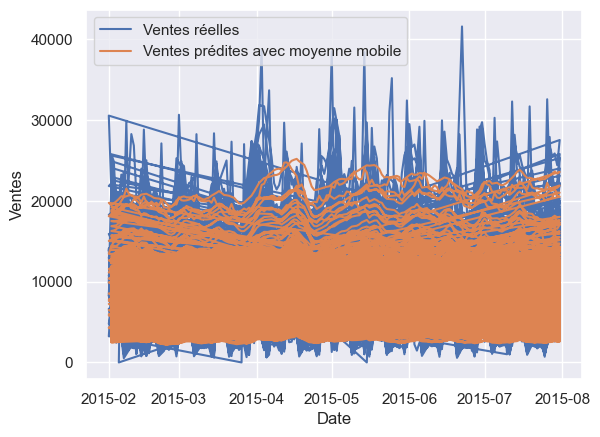

In [599]:
# Comparaison entre prévisions moyennes mobiles et données réelles sur les 6 derniers mois (février à juillet 2015)

# Sélection période 6 derniers mois

df_6mois = df_prev[(df_prev['Date'] >= '2015-02-01') & (df_prev['Date'] <= '2015-07-31')]

# Paramètres les données de ventes et les prédictions

plt.plot(df_6mois['Date'], df_6mois['Sales'], label='Ventes réelles')
plt.plot(df_6mois['Date'], df_6mois['moyenne_mobile'], label='Ventes prédites avec moyenne mobile')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.legend()

# Affichage du graphique
plt.show()

In [601]:
# Evaluer la qualité des prédictions

# Import librairie
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculer les erreurs pour la période des 6 derniers mois
mse = mean_squared_error(df_6mois['Sales'].dropna(), df_6mois['moyenne_mobile'].dropna())
mae = mean_absolute_error(df_6mois['Sales'].dropna(), df_6mois['moyenne_mobile'].dropna())

print(f'L\'erreur quadratique moyenne est de : {mse}')
print(f'L\'erreur absolue moyenne est de: {mae}')

L'erreur quadratique moyenne est de : 2951931.0547999796
L'erreur absolue moyenne est de: 1265.8253978123066


In [605]:
# Les résultats indiquent que les prédictions de mon modèle sont élevées

Les résultats indiquent que les prédictions de mon modèle sont élevées


In [607]:
# Création d'un dataframe agrégé par date des 6 derniers mois

df_agregé_par_date = df_6mois
df_agre = df_agregé_par_date.groupby('Date').mean(numeric_only=True)

df_agre = df_agre[['Sales', 'moyenne_mobile']].reset_index(level=0)

# Affichage du dataframe
df_agre

,Date,Sales,moyenne_mobile
0,2015-02-01,12530.888889,9991.507407
1,2015-02-02,9238.035907,6701.341712
2,2015-02-03,7993.429084,6730.721604
3,2015-02-04,7310.039533,6822.844325
4,2015-02-05,7157.913824,6923.333872
...,...,...,...
176,2015-07-27,9620.208446,6884.900689
177,2015-07-28,8189.643306,7001.885894
178,2015-07-29,7636.982929,7129.345193
179,2015-07-30,7905.529200,7009.846481


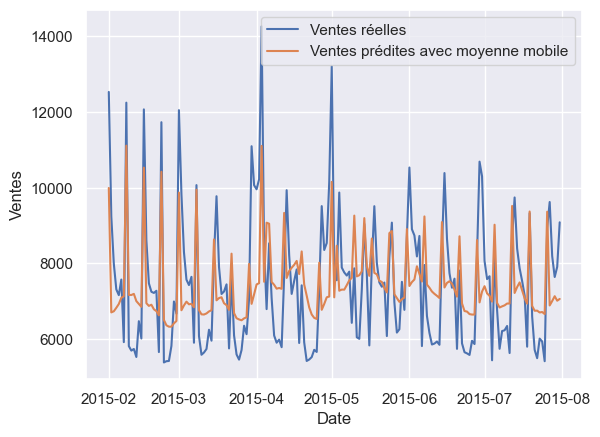

In [609]:
# Visualisation graphique

plt.plot(df_agre['Date'], df_agre['Sales'], label='Ventes réelles')
plt.plot(df_agre['Date'], df_agre['moyenne_mobile'], label='Ventes prédites avec moyenne mobile')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.legend()

# Affichage du graphique 
plt.show()

In [613]:
# Evaluer la qualité des prédictions pour le dataframe des 6 mois

# Calculer les erreurs pour la période des 6 derniers mois
mse = mean_squared_error(df_agre['Sales'].dropna(), df_agre['moyenne_mobile'].dropna())
mae = mean_absolute_error(df_agre['Sales'].dropna(), df_agre['moyenne_mobile'].dropna())

print(f'L\'erreur quadratique moyenne pour les 6 derniers mois est de : {mse}')
print(f'Tandis que l\'erreur absolue moyenne est de: {mae}')

L'erreur quadratique moyenne pour les 6 derniers mois est de : 1827306.6433980959
Tandis que l'erreur absolue moyenne est de: 1084.3926956728053


# 4. Évaluez la performance du modèle de prévision sur les différents groupes de magasin 

In [655]:
# J'essaye de visualiser les colonnes qui pourrait me poser problème
df_prev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 1014980 to 1114
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[ns]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  object        
 8   SchoolHoliday              844392 non-null  int64         
 9   année                      844392 non-null  int32         
 10  mois                       844392 non-null  int32         
 11  jour                       844392 non-null  int32    

In [657]:
# Je veux la liste des colonnes et des informations en objet

for col in df_prev.columns:
    if df_prev[col].dtype == 'object':
        print(f"Colonne {col} contient : {df_prev[col].unique()}")

Colonne StateHoliday contient : ['0' 'a' 'b' 'c']
Colonne mois_nom contient : ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']
Colonne jour_nom contient : ['Wednesday' 'Thursday' 'Friday' 'Saturday' 'Monday' 'Tuesday' 'Sunday']
Colonne StoreType contient : ['c' 'a' 'd' 'b']
Colonne Assortment contient : ['a' 'c' 'b']
Colonne PromoInterval contient : ['0' '01,04,07,10' '02,05,08,11' '03,06,09,12']


In [619]:
# Vérifier toutes les variables en mémoire et afficher celles qui sont des DataFrames
dataframes = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)}

# Afficher les noms des DataFrames
print("DataFrames disponibles :", list(dataframes.keys()))

#Cette étape est importante pour moi elle permet de lister tous les df que j'ai pu crée pour ne pas tout mélanger

DataFrames disponibles : ['__', 'df_train', '_50', '_52', 'df_store', '_69', '_71', 'df_test', 'df_sub', '_93', '_110', 'ventes_moyenne', '_144', 'ventes_moyenne_mensuel', 'CA_par_mois', 'df_clients', 'df_clients_mensuel', '_186', '_193', '_197', '_199', '_203', '_215', '_224', 'df_combine', '_230', 'df_merge2', 'df_merge', 'df_merge_resampled', '_258', '_260', '_267', 'CA_par_année', '_284', 'df_corr', 'Y_train', '_307', 'X_train', '_309', 'distances_negatives', '_345', 'df_sales_train_combine', 'correlations', 'Kmeans_combine', 'data', 'std_data', '_385', '_387', '_449', '_453', '_463', '_477', '_491', '_493', '_495', '_501', 'Kmeans_train', '_515', '_543', '_549', 'df_prev', '_551', '_553', 'store_data', 'filtre_prev', '_585', '_587', '_589', '_591', '_593', '_595', '_597', 'df_6mois', 'df_agregé_par_date', 'df_agre', '_607', '_615', '_617']


In [659]:
#Problème lors de la fusion et les moyennes demandées
# Nettoyge des données avant la fusion

# Supprimer les colonnes inutiles
colonnes_a_supprimer = ['StateHoliday', 'mois_nom', 'jour_nom', 'PromoInterval']
df_prev2 = df_prev.drop(columns=colonnes_a_supprimer, errors='ignore')

# Conversion des valeurs dans StoreType
storetype_mapping = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
df_prev2['StoreType'] = df_prev['StoreType'].map(storetype_mapping)

# Conversion des valeurs dans Assortment
assortment_mapping = {'a': 1, 'b': 2, 'c': 3}
df_prev2['Assortment'] = df_prev2['Assortment'].map(assortment_mapping)

# Vérification du résultat
print(df_prev2.head())

         Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
1014980      1          3 2013-01-02   5530        668     1      0   
1013865      1          4 2013-01-03   4327        578     1      0   
1012750      1          5 2013-01-04   4486        619     1      0   
1011635      1          6 2013-01-05   4997        635     1      0   
1009405      1          1 2013-01-07   7176        785     1      1   

         SchoolHoliday  année  mois  jour  StoreType  Assortment  \
1014980              1   2013     1     2          3           1   
1013865              1   2013     1     3          3           1   
1012750              1   2013     1     4          3           1   
1011635              1   2013     1     5          3           1   
1009405              1   2013     1     7          3           1   

         CompetitionDistance  CompetitionOpenSinceMonth  \
1014980               1270.0                        9.0   
1013865               1270.0                  

In [663]:
# Ajout des catégories de clusters dans le dataframe des ventes et agrégé par date et clusters filtré sur 6 derniers mois

df_merge3 = df_merge[['Store', 'cluster']]

#Fusion des fichiers  df_prev et df_aggregated5
df_clusters = pd.merge(df_prev2, df_merge3, how='left', on='Store')

#suppression colonne promointerval inutiles

df_clusters = df_clusters.drop('PromoInterval', axis=1)

#Regourper les données par date et clusters en calculant la moyenne

df_regroupe = df_clusters.groupby(['Date', 'cluster']).mean().reset_index()

#Dataframe filtré sur les 6 derniers mois

df_6_derniers_mois = df_regroupe[(df_regroupe['Date'] >= '2015-02-01') & (df_regroupe['Date'] <= '2015-07-31')]
df_6_derniers_mois

,Date,cluster,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,année,mois,jour,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,moyenne_mobile
2986,2015-02-01,1,877.000000,7.0,3230.000000,448.000000,1.0,0.0,0.000000,2015.0,2.0,1.0,1.000000,3.000000,29190.000000,NaN,NaN,0.000000,NaN,NaN,5806.666667
2987,2015-02-01,2,613.272727,7.0,15425.000000,2582.000000,1.0,0.0,0.000000,2015.0,2.0,1.0,2.000000,1.727273,851.818182,6.833333,2007.000000,0.181818,39.500000,2012.500000,12548.042424
2988,2015-02-01,3,466.500000,7.0,8775.166667,1427.500000,1.0,0.0,0.000000,2015.0,2.0,1.0,2.000000,1.500000,1443.333333,6.333333,2009.333333,0.500000,9.666667,2013.000000,6002.000000
2989,2015-02-02,0,548.298663,1.0,7929.136701,719.485884,1.0,1.0,0.124814,2015.0,2.0,2.0,2.427935,1.924220,3375.940299,7.328918,2008.430464,0.609212,24.153659,2011.731707,5844.794948
2990,2015-02-02,1,551.506250,1.0,9377.456250,829.093750,1.0,1.0,0.243750,2015.0,2.0,2.0,2.243750,2.100000,20737.125000,6.933333,2008.980952,0.387500,20.774194,2011.403226,6471.614167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3694,2015-07-30,3,583.923372,4.0,9626.831418,1060.329502,1.0,1.0,0.915709,2015.0,7.0,30.0,1.712644,1.831418,1595.670498,7.157068,2009.052356,0.367816,22.531250,2012.125000,8685.683014
3695,2015-07-31,0,548.680060,5.0,7898.647321,695.354167,1.0,1.0,0.796131,2015.0,7.0,31.0,2.430060,1.925595,3379.342302,7.331858,2008.429204,0.610119,24.153659,2011.731707,6125.928075
3696,2015-07-31,1,549.465409,5.0,9184.308176,818.484277,1.0,1.0,0.867925,2015.0,7.0,31.0,2.251572,2.106918,20730.503145,6.961538,2009.019231,0.383648,20.819672,2011.344262,7167.890985
3697,2015-07-31,2,596.190476,5.0,18069.714286,2643.333333,1.0,1.0,1.000000,2015.0,7.0,31.0,1.523810,1.952381,664.761905,6.916667,2008.833333,0.142857,39.666667,2012.000000,15013.803175


In [665]:
# Vérification du type de données dans le nouveau df
df_6_derniers_mois.info()

<class 'pandas.core.frame.DataFrame'>
Index: 713 entries, 2986 to 3698
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       713 non-null    datetime64[ns]
 1   cluster                    713 non-null    int32         
 2   Store                      713 non-null    float64       
 3   DayOfWeek                  713 non-null    float64       
 4   Sales                      713 non-null    float64       
 5   Customers                  713 non-null    float64       
 6   Open                       713 non-null    float64       
 7   Promo                      713 non-null    float64       
 8   SchoolHoliday              713 non-null    float64       
 9   année                      713 non-null    float64       
 10  mois                       713 non-null    float64       
 11  jour                       713 non-null    float64       
 12  StoreType

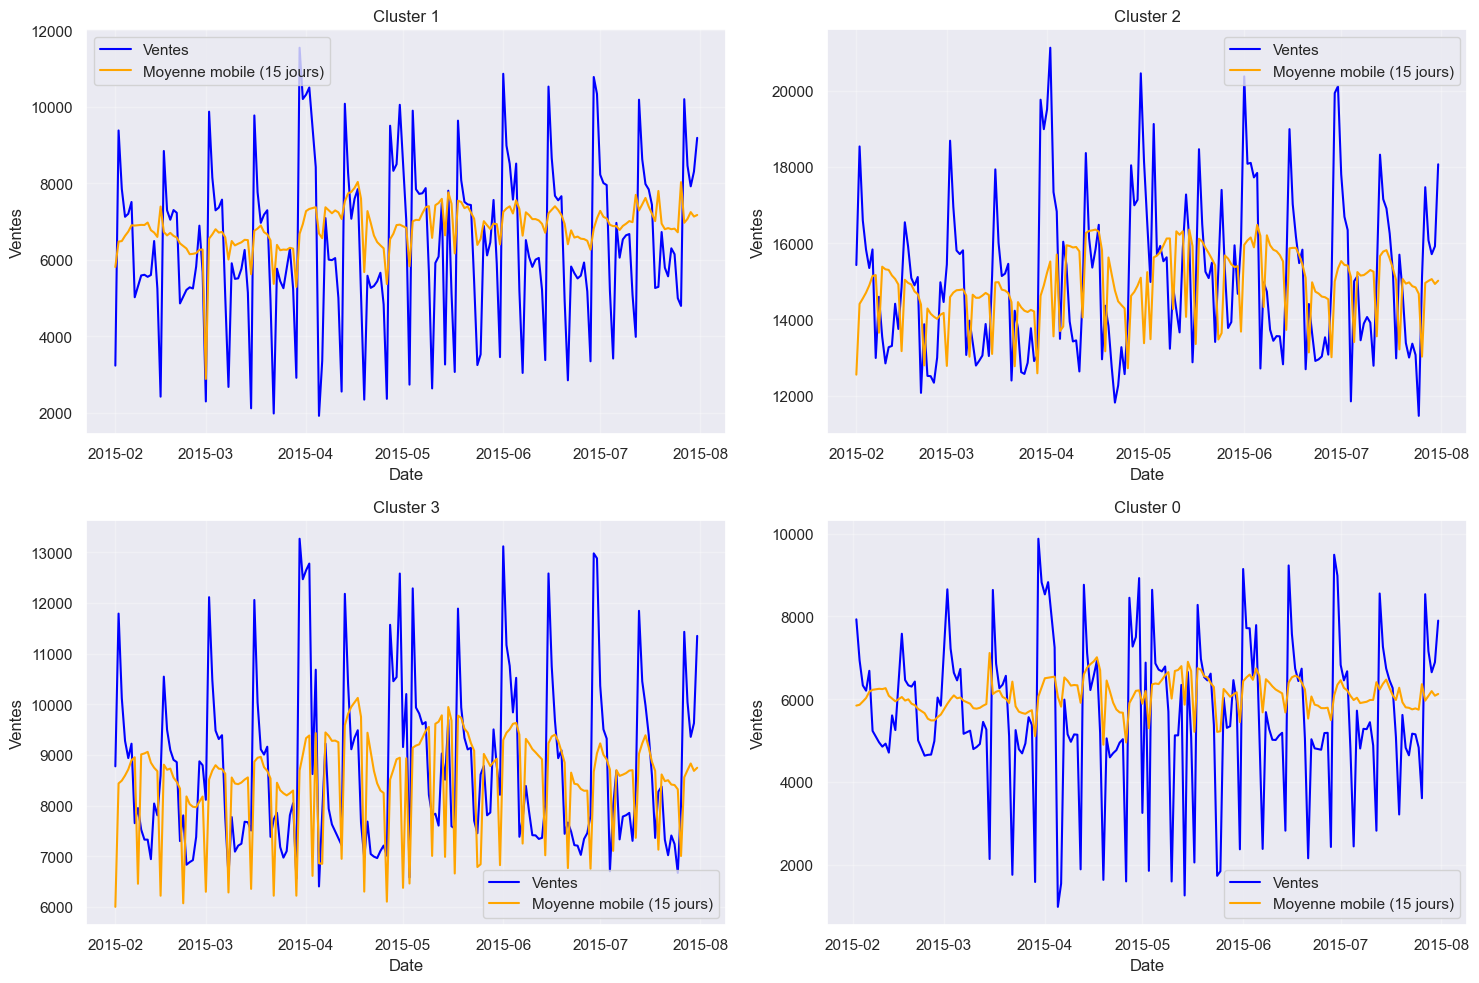

In [669]:
# Séparez le dataframe en sous-dataframes pour chaque cluster
clusters = df_6_derniers_mois['cluster'].unique()
cluster_data = {cluster: df_6_derniers_mois[df_6_derniers_mois['cluster'] == cluster] for cluster in clusters}

# Configuration de la figure
plt.figure(figsize=(15, 10))

# Boucle pour créer les sous-graphiques
for i, cluster in enumerate(clusters):
    plt.subplot(2, 2, i + 1)
    plt.plot(cluster_data[cluster]['Date'], cluster_data[cluster]['Sales'], label='Ventes', color='blue')
    plt.plot(cluster_data[cluster]['Date'], cluster_data[cluster]['moyenne_mobile'], label='Moyenne mobile (15 jours)', color='orange')
    plt.title(f'Cluster {cluster}')
    plt.xlabel('Date')
    plt.ylabel('Ventes')
    plt.legend()
    plt.grid(alpha=0.3)

# Ajuster les espaces entre les sous-graphiques
plt.tight_layout()

# Afficher les graphiques
plt.show()

In [671]:
# Calcul moyenne ventes par cluster des 6 derniers mois

moyenne_sales_clusters = df_6_derniers_mois.groupby('cluster')['Sales'].mean()
moyenne_sales_clusters

cluster
0     5621.721578
1     6412.816338
2    15080.328886
3     8730.333068
Name: Sales, dtype: float64

In [673]:
# Le cluster 2 à la moyenne la plus forte et le cluster 0 la plus faible

Le cluster 2 à la moyenne la plus forte et le cluster 0 la plus faible


In [677]:
# Calcul moyenne moyenne mobile par clusters 6 derniers mois

moyenne_mob_clusters = df_6_derniers_mois.groupby('cluster')['moyenne_mobile'].mean()
moyenne_mob_clusters

cluster
0     6100.920325
1     6840.281516
2    14898.786327
3     8519.905432
Name: moyenne_mobile, dtype: float64

In [679]:
# Le cluster 2 est également le cluster le plus important et le cluster 1 le plus faible

Le cluster 2 est également le cluster le plus important et le cluster 1 le plus faible


In [681]:
# Liste des clusters uniques
clusters = df_6_derniers_mois['cluster'].unique()

# Calcul et affichage des erreurs pour chaque cluster
for cluster in clusters:
    cluster_data = df_6_derniers_mois[df_6_derniers_mois['cluster'] == cluster]
    mse = mean_squared_error(cluster_data['Sales'].dropna(), cluster_data['moyenne_mobile'].dropna())
    mae = mean_absolute_error(cluster_data['Sales'].dropna(), cluster_data['moyenne_mobile'].dropna())
    
    print(f"Cluster {cluster}:")
    print(f"  L\'erreur quadratique moyenne pour les 6 derniers mois est de : {mse}")
    print(f"  Tandis que l\'erreur absolue moyenne est de: {mae}")
    print("-" * 40)

print(f'L\'erreur quadratique moyenne pour les 6 derniers mois est de : {mse}')
print(f'Tandis que l\'erreur absolue moyenne est de: {mae}')

Cluster 1:
  L'erreur quadratique moyenne pour les 6 derniers mois est de : 3698089.1025792584
  Tandis que l'erreur absolue moyenne est de: 1523.113840535843
----------------------------------------
Cluster 2:
  L'erreur quadratique moyenne pour les 6 derniers mois est de : 4305111.683459515
  Tandis que l'erreur absolue moyenne est de: 1726.1034162461235
----------------------------------------
Cluster 3:
  L'erreur quadratique moyenne pour les 6 derniers mois est de : 2445224.9731626133
  Tandis que l'erreur absolue moyenne est de: 1272.531502232557
----------------------------------------
Cluster 0:
  L'erreur quadratique moyenne pour les 6 derniers mois est de : 3133796.4486697474
  Tandis que l'erreur absolue moyenne est de: 1334.9751981181328
----------------------------------------
L'erreur quadratique moyenne pour les 6 derniers mois est de : 3133796.4486697474
Tandis que l'erreur absolue moyenne est de: 1334.9751981181328


In [683]:
#Import pour test des prédictions 

from sklearn.metrics import pairwise_distances_argmin_min

In [689]:
#instancier le scaling
scaler = StandardScaler()

# Entrainer le scaler 
scaler.fit(df_merge)

# On transforme les données
X_scaled = scaler.transform(df_merge)
X_scaled[:10]

array([[-1.73049809, -0.02828801, -0.88857955, -0.50826008, -0.53982347,
         0.43851027, -1.02451567,  1.97454904, -0.71068302],
       [-1.72739128,  0.09700518, -0.80190926, -0.4504817 , -0.63121052,
         0.43851027,  0.97607097, -0.06574951, -0.71068302],
       [-1.72428446, -0.11181681, -0.01078783, -0.02892819,  1.13908726,
         0.43851027,  0.97607097,  0.16966955,  0.09379573],
       [-1.72117764,  0.09700518,  1.10409022,  1.47768346, -0.62468287,
         0.43851027, -1.02451567,  0.40508862,  1.70275323],
       [-1.71807082, -0.11181681, -0.92700211, -0.58138314,  3.19921256,
         0.43851027, -1.02451567,  0.3266156 ,  0.09379573],
       [-1.714964  , -0.07005241, -0.58710703, -0.32504407, -0.66515428,
         0.43851027, -1.02451567,  0.3266156 , -0.71068302],
       [-1.71185718,  0.18053398,  0.77905589,  0.50864878,  2.42764472,
         0.43851027, -1.02451567, -0.69353368,  0.09379573],
       [-1.70875036,  0.09700518, -0.56370195, -0.25655808,  0

In [701]:
# Imports 

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Assurez-vous que X_scaled provient d'un DataFrame original
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_merge)  

# Reconvertir X_scaled en DataFrame pour garder les colonnes
X_scaled = pd.DataFrame(X_scaled, columns=df_merge.columns)

# Imputer les valeurs manquantes
imputer = SimpleImputer(strategy='mean')
X_scaled_cleaned = imputer.fit_transform(X_scaled)

# Reconvertir X_scaled_cleaned en DataFrame avec les colonnes originales
X_scaled_cleaned = pd.DataFrame(X_scaled_cleaned, columns=X_scaled.columns)

# Appliquer le KMeans
kmeans_états = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_états.fit(X_scaled_cleaned)

# Prédire les clusters
clusters = kmeans_états.predict(X_scaled_cleaned)

# Vérification
print("Clusters prédits : ", clusters)

Clusters prédits :  [2 0 3 ... 2 1 0]


In [709]:
# Instancier le k-means

kmeans_états = KMeans(n_clusters=4, init = 'k-means++')

# Entrainer le k-means

kmeans_états.fit(X_scaled_cleaned)
                       
# On récupère les clusters

clusters = kmeans_états.predict(X_scaled_cleaned)

In [711]:
# Import

from sklearn.metrics import pairwise_distances_argmin_min

# Vérifiez que le modèle est entraîné
if hasattr(kmeans_états, 'cluster_centers_'):
    centroides = kmeans_états.cluster_centers_
else:
    raise ValueError("Le modèle KMeans n'est pas correctement entraîné.")

# Trouver les magasins les plus proches des centroïdes
closest, _ = pairwise_distances_argmin_min(centroides, X_scaled_cleaned)

# Assurez-vous que df_merge a les informations nécessaires
if 'Store' not in df_merge.columns or 'cluster' not in df_merge.columns:
    raise ValueError("Les colonnes 'Store' ou 'cluster' sont absentes du dataframe df_merge.")

# Extraire les informations des magasins correspondant aux centroïdes
magasins_centroides = df_merge.iloc[closest][['Store', 'cluster']]

# Afficher les résultats
print("Magasins représentant les centroïdes pour chaque cluster :")
print(magasins_centroides)

Magasins représentant les centroïdes pour chaque cluster :
     Store  cluster
577    578        1
590    591        0
475    476        0
667    668        3


In [723]:
# Il y a un problème lié aux clusters. Il y a deux clusters 0

Il y a un problème lié aux clusters. Il y a deux clusters 0


In [713]:
df_merge['cluster'] = clusters
print(df_merge['cluster'].value_counts())

cluster
2    431
1    397
3    258
0     29
Name: count, dtype: int64


In [715]:
distances = pairwise_distances_argmin_min(centroides, X_scaled_cleaned)
print(distances)

(array([577, 590, 475, 667]), array([2.56537072, 1.24455718, 0.57812856, 0.76860103]))


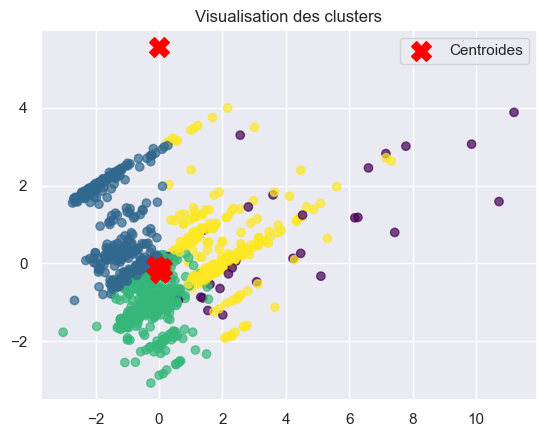

In [719]:
# Import

from sklearn.decomposition import PCA

# Réduction de dimensions pour la visualisation
pca = PCA(n_components=4)
reduced_data = pca.fit_transform(X_scaled_cleaned)

plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.legend()
plt.title('Visualisation des clusters')
plt.show()

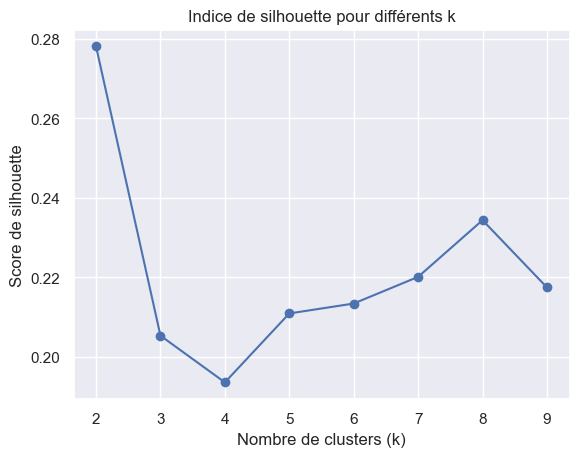

In [721]:
# Import 

from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_cleaned)
    silhouette_scores.append(silhouette_score(X_scaled_cleaned, kmeans.labels_))

plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Indice de silhouette pour différents k')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de silhouette')
plt.show()

In [725]:
# Test avec 2 clusters
kmeans_2 = KMeans(n_clusters=2, random_state=42)
clusters_2 = kmeans_2.fit_predict(X_scaled_cleaned)
centroides_2 = kmeans_2.cluster_centers_

## 4.1 Analyse avec 2 clusters

In [727]:
# Analyse des 2 clusters obtenus
df_merge['cluster'] = clusters_2
print(df_merge['cluster'].value_counts())

cluster
0    824
1    291
Name: count, dtype: int64


In [729]:
df_cluster_analysis = df_merge.groupby('cluster').mean()
print("Caractéristiques moyennes par cluster :")
print(df_cluster_analysis)

Caractéristiques moyennes par cluster :
              Store      Open        Sales   Customers  CompetitionDistance  \
cluster                                                                       
0        547.544903  0.827111  5049.117505  502.467730          6591.047503   
1        587.604811  0.837438  7785.668656  989.201206          2058.419244   

            Promo    Promo2  SchoolHoliday  
cluster                                     
0        0.381235  0.571602       0.176974  
1        0.381798  0.343643       0.181562  


In [731]:
# Trouver les magasins les plus proches des centroïdes
closest, _ = pairwise_distances_argmin_min(centroides_2, X_scaled_cleaned)

# Extraire les informations des magasins
magasins_centroides = df_merge.iloc[closest][['Store', 'cluster']]
print("Magasins représentant les centroïdes pour chaque cluster :")
print(magasins_centroides)

Magasins représentant les centroïdes pour chaque cluster :
     Store  cluster
563    564        0
667    668        1


In [739]:
# Centroïdes des clusters

centroides_df = pd.DataFrame(centroides_2, columns=X_scaled_cleaned.columns)
print("Coordonnées des centroïdes :")
print(centroides_df)

Coordonnées des centroïdes :
      Store      Open     Sales  Customers  CompetitionDistance     Promo  \
0 -0.032482 -0.106031 -0.349153  -0.398912             0.154291 -0.082305   
1  0.091977  0.300239  0.988667   1.129565            -0.436893  0.233057   

     Promo2  SchoolHoliday   cluster  
0  0.119024      -0.088510 -0.563260  
1 -0.337029       0.250625  1.594936  


In [741]:
# Trouver les magasins les plus proches des centroïdes
closest, _ = pairwise_distances_argmin_min(centroides_2, X_scaled_cleaned)

# Extraire les informations des magasins
magasins_centroides = df_merge.iloc[closest][['Store', 'cluster']]
print("Magasins représentant les centroïdes pour chaque cluster :")
print(magasins_centroides)

Magasins représentant les centroïdes pour chaque cluster :
     Store  cluster
563    564        0
667    668        1


In [755]:
print(clusters_2.shape)
print(centroides_2.shape)

(1115,)
(2, 9)


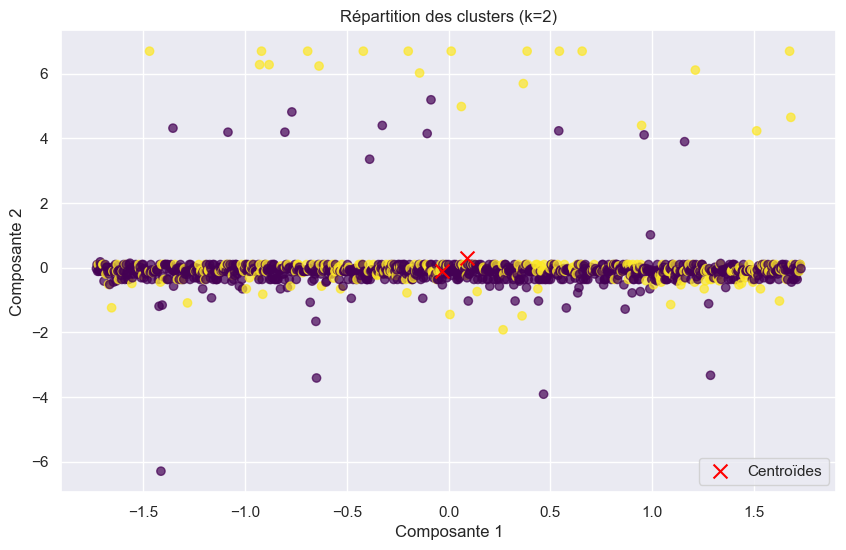

In [759]:
# Assurez-vous que X_scaled_cleaned est une matrice 2D
X_scaled_cleaned = np.array(X_scaled_cleaned)  # Si ce n'est pas déjà un array numpy
plt.figure(figsize=(10, 6))

# Scatter plot des points
plt.scatter(X_scaled_cleaned[:, 0], X_scaled_cleaned[:, 1], c=clusters_2, cmap='viridis', alpha=0.7)

# Scatter plot des centroïdes
plt.scatter(centroides_2[:, 0], centroides_2[:, 1], c='red', marker='x', s=100, label='Centroïdes')

# Ajouter des titres et labels
plt.title("Répartition des clusters (k=2)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend()

# Afficher le graphique
plt.show()

## 4.2 Prédiction avec SARIMA

In [779]:
# Import de SARIMA

import statsmodels.api as sm

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



MSE pour les ventes non filtrées : 4020529497537.2363
MAE pour les ventes non filtrées : 1406987.1703134263


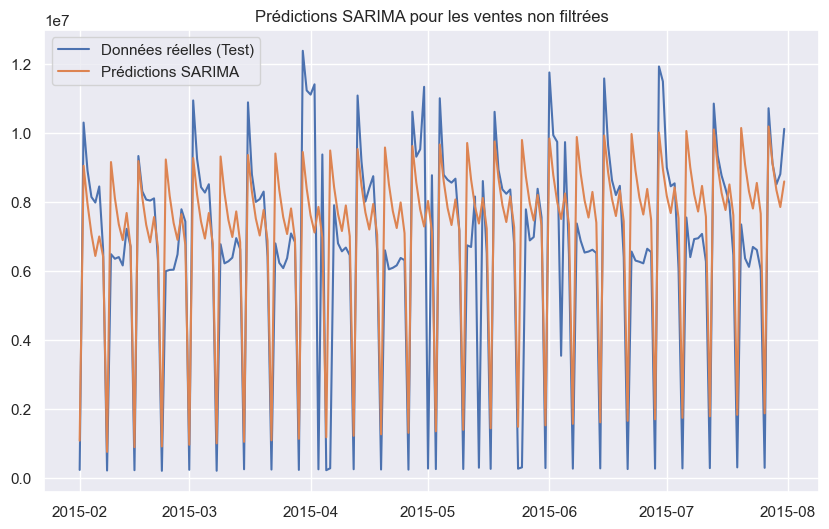

In [783]:
# Agréger df_clusters par ventes pour plus avoir le détails par magasins
global_sales = df_clusters.groupby('Date')['Sales'].sum()

# Diviser les données en train (période entrainement) et test (période prédictions, 6 derniers mois)
train_data = global_sales[:'2015-01-31']
test_data = global_sales['2015-02-01':]

# Paramètres du modèle SARIMA
p, d, q = 1, 1, 1
P, D, Q, m = 1, 1, 1, 7  # Saison hebdomadaire

# Ajuster le modèle SARIMA
sarima_model = sm.tsa.SARIMAX(train_data, order=(p,d,q), seasonal_order=(P,D,Q,m))
sarima_fit = sarima_model.fit(disp=False)

# Prédictions pour la période de test (6 mois)
forecast_sarima = sarima_fit.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)

# Calcul mse et mae
mse = mean_squared_error(test_data, forecast_sarima)
mae = mean_absolute_error(test_data, forecast_sarima)
print(f"MSE pour les ventes non filtrées : {mse}")
print(f"MAE pour les ventes non filtrées : {mae}")

# Visualisation des résultats
plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data, label='Données réelles (Test)')
plt.plot(test_data.index, forecast_sarima, label='Prédictions SARIMA')
plt.legend()
plt.title('Prédictions SARIMA pour les ventes non filtrées')
plt.show()

## 4.3 Prévision par cluster 

Traitement pour le cluster 0...
Cluster 0 - MSE : 1372225750290.3215, MAE : 833672.3841174226


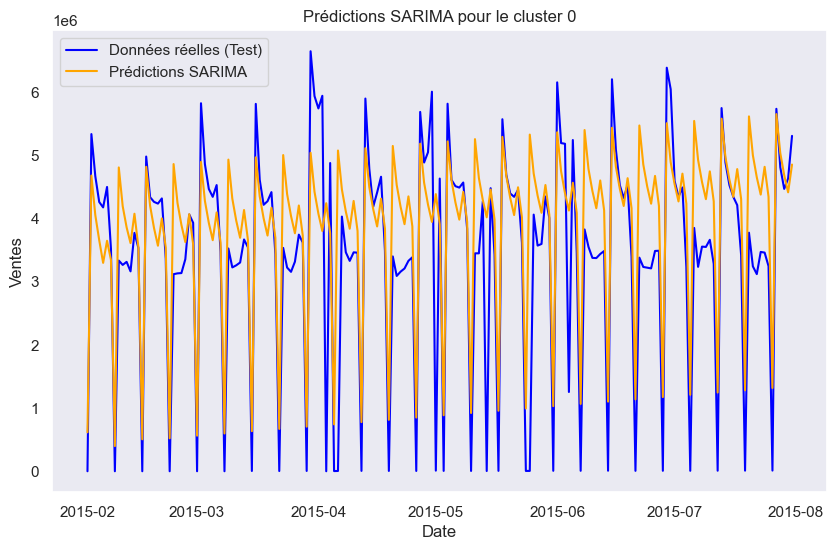

Traitement pour le cluster 1...
Cluster 1 - MSE : 80163182555.0916, MAE : 190713.0528635984


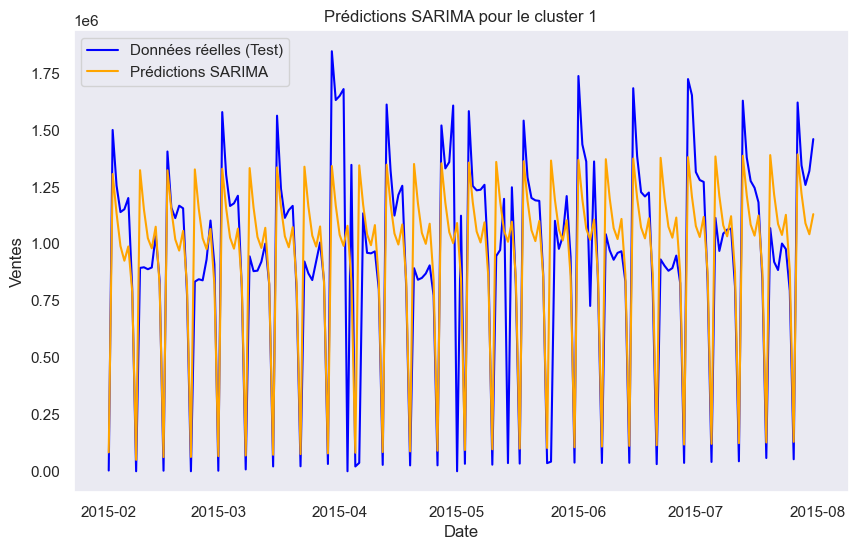

In [787]:
# Liste des clusters à analyser
clusters_to_analyze = [0, 1]

# Paramètres SARIMA (à ajuster selon vos données)
p, d, q = 1, 1, 1
P, D, Q, m = 1, 1, 1, 7  # Saison hebdomadaire

# Résultats pour chaque cluster
results = {}

for cluster in clusters_to_analyze:
    print(f"Traitement pour le cluster {cluster}...")
    
    # Filtrer les données pour le cluster
    cluster_data = df_clusters[df_clusters['cluster'] == cluster]
    
    # Conversion des dates
    cluster_data.loc[:, 'Date'] = pd.to_datetime(cluster_data['Date'])
    
    # Agrégation des ventes par date
    cluster_sales = cluster_data.groupby('Date')['Sales'].sum()
    
    # Ajout de la fréquence explicite pour les dates
    cluster_sales = cluster_sales.asfreq('D').fillna(0)  # Remplir les valeurs manquantes avec 0
    
    # Diviser les données en train et test
    train_data = cluster_sales[:'2015-01-31']
    test_data = cluster_sales['2015-02-01':]
    
    # Ajuster le modèle SARIMA
    sarima_model = sm.tsa.SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, m))
    sarima_fit = sarima_model.fit(disp=False)
    
    # Prédictions pour la période de test
    forecast_sarima = sarima_fit.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)
    
    # Calcul des métriques
    mse = mean_squared_error(test_data, forecast_sarima)
    mae = mean_absolute_error(test_data, forecast_sarima)
    
    # Sauvegarder les résultats
    results[cluster] = {
        'train_data': train_data,
        'test_data': test_data,
        'forecast': forecast_sarima,
        'mse': mse,
        'mae': mae
    }
    
    # Afficher les résultats
    print(f"Cluster {cluster} - MSE : {mse}, MAE : {mae}")
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(test_data.index, test_data, label='Données réelles (Test)', color='blue')
    plt.plot(test_data.index, forecast_sarima, label='Prédictions SARIMA', color='orange')
    plt.title(f'Prédictions SARIMA pour le cluster {cluster}')
    plt.xlabel('Date')
    plt.ylabel('Ventes')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# Je vais prendre un autre magasin dans les clusters pour comparer

In [791]:
# Filtrer le DataFrame pour le magasin 403
store_403_data = df_clusters[df_clusters['Store'] == 403]

# Afficher les premières lignes du DataFrame filtré
print(store_403_data.head())

        Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
304605    403          3 2013-01-02   7714        825     1      0   
304606    403          4 2013-01-03   6174        611     1      0   
304607    403          5 2013-01-04   6686        711     1      0   
304608    403          6 2013-01-05   4170        456     1      0   
304609    403          1 2013-01-07  11799       1057     1      1   

        SchoolHoliday  année  mois  jour  StoreType  Assortment  \
304605              1   2013     1     2          1           1   
304606              1   2013     1     3          1           1   
304607              1   2013     1     4          1           1   
304608              0   2013     1     5          1           1   
304609              0   2013     1     7          1           1   

        CompetitionDistance  CompetitionOpenSinceMonth  \
304605               4970.0                        7.0   
304606               4970.0                        7.0   
30

Traitement pour Cluster 0 Centroïde (Store 564)...
Cluster 0 Centroïde - MSE : 2302064.799105736, MAE : 976.6068661090994


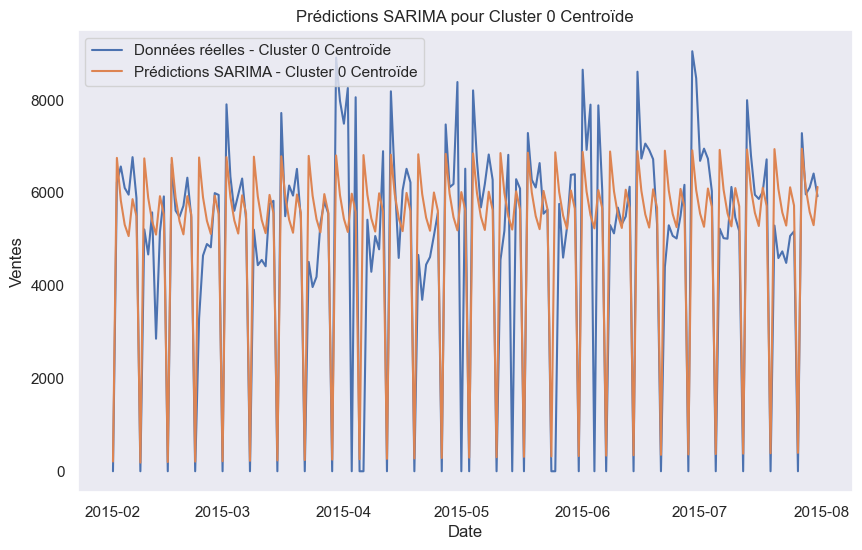

Traitement pour Cluster 0 Magasin 403 (Store 403)...
Cluster 0 Magasin 403 - MSE : 3333603.2329449877, MAE : 1097.2994807398495


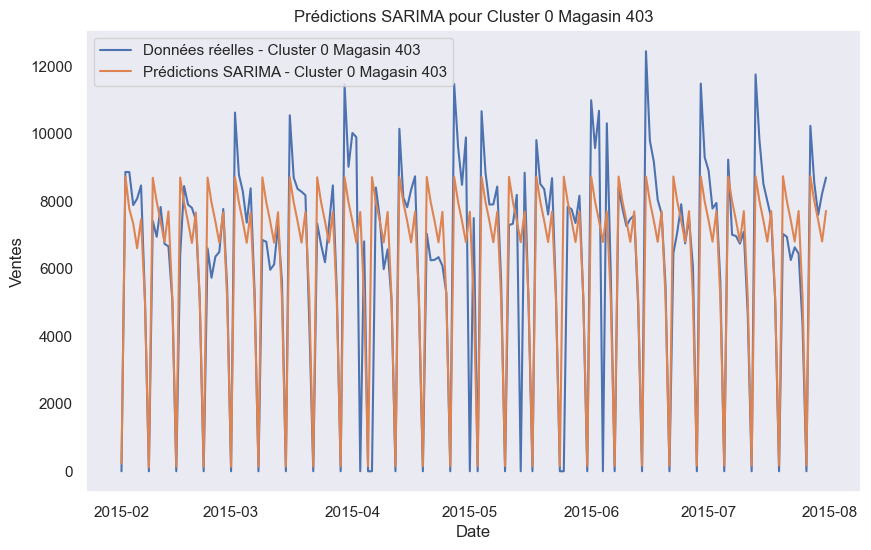

In [795]:
# Cluster 0 : centroïde (Store 564) et un autre magasin du cluster
cluster_0_centroide = 564
cluster_0_other_store = 403  # Autre magasin du cluster

stores_to_compare = {
    "Cluster 0 Centroïde": cluster_0_centroide,
    "Cluster 0 Magasin 403": cluster_0_other_store
}

for label, store in stores_to_compare.items():
    print(f"Traitement pour {label} (Store {store})...")
    
    # Filtrer les données pour le magasin
    store_data = df_clusters[df_clusters['Store'] == store]
    store_data.loc[:, 'Date'] = pd.to_datetime(store_data['Date'])
    
    # Agrégation des ventes par date
    store_sales = store_data.groupby('Date')['Sales'].sum()
    store_sales = store_sales.asfreq('D').fillna(0)
    
    # Diviser les données en train et test
    train_data = store_sales[:'2015-01-31']
    test_data = store_sales['2015-02-01':]
    
    # Ajuster le modèle SARIMA
    sarima_model = sm.tsa.SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, m))
    sarima_fit = sarima_model.fit(disp=False)
    
    # Prédictions
    forecast_sarima = sarima_fit.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)
    
    # Calcul des métriques
    mse = mean_squared_error(test_data, forecast_sarima)
    mae = mean_absolute_error(test_data, forecast_sarima)
    print(f"{label} - MSE : {mse}, MAE : {mae}")
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(test_data.index, test_data, label=f'Données réelles - {label}')
    plt.plot(test_data.index, forecast_sarima, label=f'Prédictions SARIMA - {label}')
    plt.title(f'Prédictions SARIMA pour {label}')
    plt.xlabel('Date')
    plt.ylabel('Ventes')
    plt.legend()
    plt.grid()
    plt.show()

In [799]:
# Filtrer les magasins appartenant au cluster 1
cluster_1_stores = df_clusters[df_clusters['cluster'] == 1]['Store']

# Afficher la liste des magasins uniques du cluster 1
cluster_1_store_list = cluster_1_stores.unique()
print(f"Magasins dans le cluster 1 : {cluster_1_store_list}")

Magasins dans le cluster 1 : [   3    5    7   18   49   53   64   65   71   75   76   82   93   94
   98  100  110  113  122  123  138  144  150  153  154  160  168  174
  181  187  194  201  212  221  229  232  249  252  258  261  272  280
  298  299  303  307  313  315  318  322  324  342  343  348  364  375
  382  396  429  430  433  434  453  454  457  460  462  467  474  484
  489  503  517  521  524  528  529  530  561  578  579  588  593  600
  608  634  635  649  652  669  673  686  688  689  711  715  720  725
  726  728  731  732  741  745  747  755  758  763  764  765  767  771
  779  780  783  792  801  805  808  809  814  823  824  837  841  853
  859  863  867  876  877  886  887  889  892  898  910  911  918  932
  935  943  945  953  963  972  982  990  999 1001 1030 1034 1035 1038
 1045 1046 1050 1054 1069 1079]


In [797]:
# Filtrer le DataFrame pour le magasin 403
store_x_data = df_clusters[df_clusters['cluster'] == 1]

# Afficher les premières lignes du DataFrame filtré
print(store_x_data.head()

      Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
1565      3          3 2013-01-02   6823        805     1      0   
1566      3          4 2013-01-03   5902        721     1      0   
1567      3          5 2013-01-04   6069        690     1      0   
1568      3          6 2013-01-05   4523        525     1      0   
1569      3          1 2013-01-07  12247       1079     1      1   

      SchoolHoliday  année  mois  jour  StoreType  Assortment  \
1565              1   2013     1     2          1           1   
1566              1   2013     1     3          1           1   
1567              1   2013     1     4          1           1   
1568              0   2013     1     5          1           1   
1569              0   2013     1     7          1           1   

      CompetitionDistance  CompetitionOpenSinceMonth  \
1565              14130.0                       12.0   
1566              14130.0                       12.0   
1567              14130.0       

Traitement pour Cluster 1 Centroïde (Store 668)...
Cluster 1 Centroïde - MSE : 5419063.030136845, MAE : 1562.1528139187544


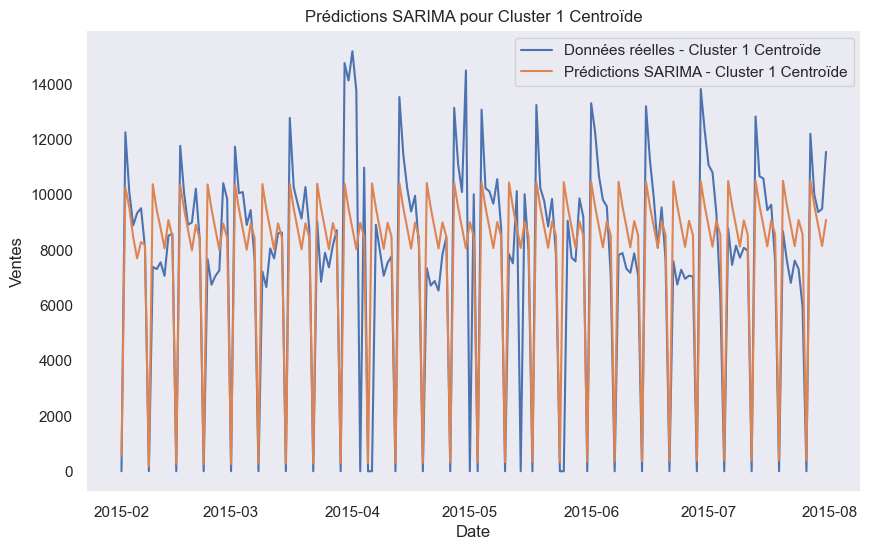

Traitement pour Cluster 1 Magasin 634 (Store 634)...
Cluster 1 Magasin 634 - MSE : 4439305.265322298, MAE : 1519.6938419343412


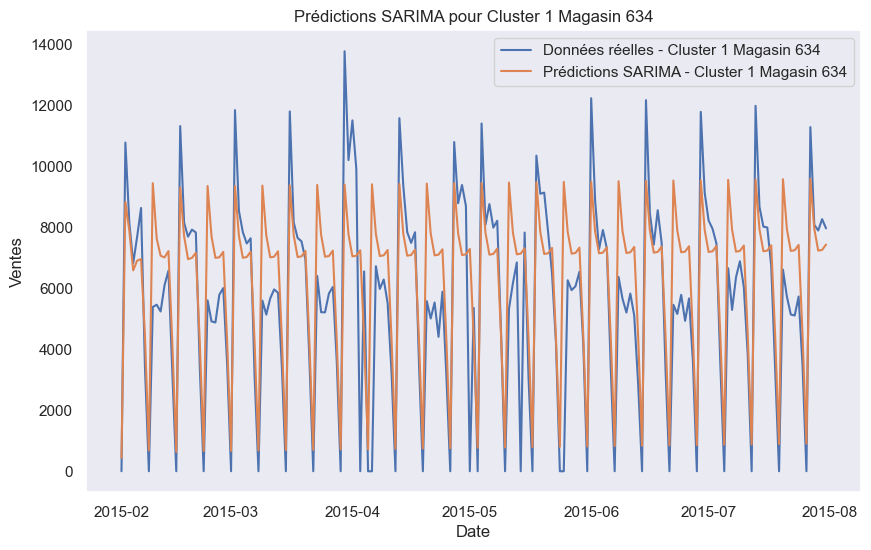

In [803]:
# Cluster 1 : centroïde (Store 668) et un autre magasin du cluster
cluster_1_centroide = 668
cluster_1_other_store = 634  # Autre magasin du cluster

stores_to_compare = {
    "Cluster 1 Centroïde": cluster_1_centroide,
    "Cluster 1 Magasin 634": cluster_1_other_store
}

for label, store in stores_to_compare.items():
    print(f"Traitement pour {label} (Store {store})...")
    
    # Filtrer les données pour le magasin
    store_data = df_clusters[df_clusters['Store'] == store]
    store_data.loc[:, 'Date'] = pd.to_datetime(store_data['Date'])
    
    # Agrégation des ventes par date
    store_sales = store_data.groupby('Date')['Sales'].sum()
    store_sales = store_sales.asfreq('D').fillna(0)
    
    # Diviser les données en train et test
    train_data = store_sales[:'2015-01-31']
    test_data = store_sales['2015-02-01':]
    
    # Ajuster le modèle SARIMA
    sarima_model = sm.tsa.SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, m))
    sarima_fit = sarima_model.fit(disp=False)
    
    # Prédictions
    forecast_sarima = sarima_fit.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)
    
    # Calcul des métriques
    mse = mean_squared_error(test_data, forecast_sarima)
    mae = mean_absolute_error(test_data, forecast_sarima)
    print(f"{label} - MSE : {mse}, MAE : {mae}")
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(test_data.index, test_data, label=f'Données réelles - {label}')
    plt.plot(test_data.index, forecast_sarima, label=f'Prédictions SARIMA - {label}')
    plt.title(f'Prédictions SARIMA pour {label}')
    plt.xlabel('Date')
    plt.ylabel('Ventes')
    plt.legend()
    plt.grid()
    plt.show()

Traitement pour Cluster 1 Centroïde (Store 668)...
Cluster 1 Centroïde - MSE : 5419063.030136845, MAE : 1562.1528139187544


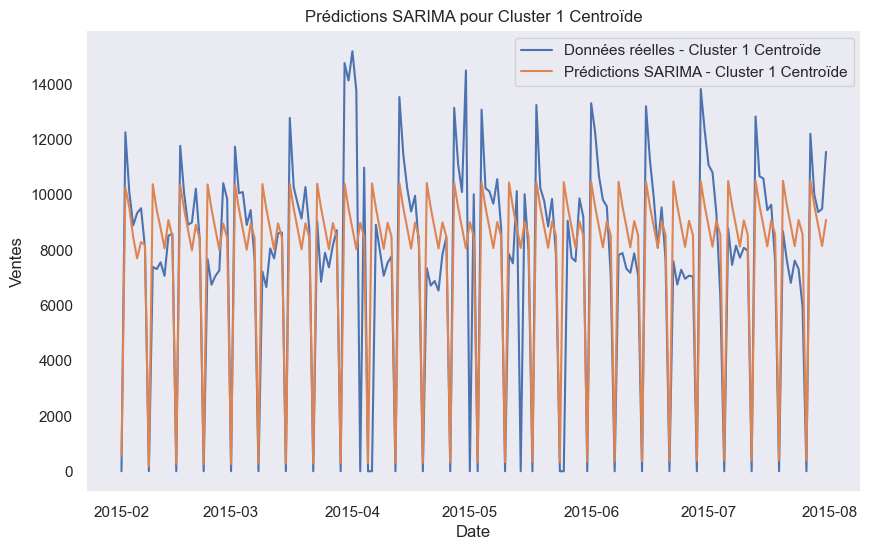

Traitement pour Cluster 1 Magasin 608 (Store 608)...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Cluster 1 Magasin 608 - MSE : 8325887.118413036, MAE : 1960.24104741733


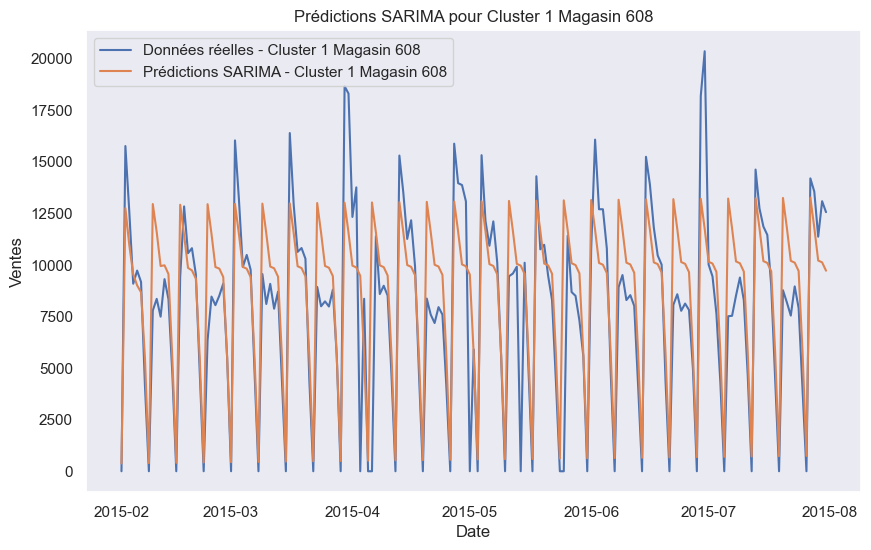

In [805]:
# Cluster 0 : centroïde (Store 668) et un autre magasin du cluster
cluster_1_608_centroide = 668
cluster_1_608_store = 608  # Autre magasin du cluster

stores_to_compare = {
    "Cluster 1 Centroïde": cluster_1_608_centroide,
    "Cluster 1 Magasin 608": cluster_1_608_store
}

for label, store in stores_to_compare.items():
    print(f"Traitement pour {label} (Store {store})...")
    
    # Filtrer les données pour le magasin
    store_data = df_clusters[df_clusters['Store'] == store]
    store_data.loc[:, 'Date'] = pd.to_datetime(store_data['Date'])
    
    # Agrégation des ventes par date
    store_sales = store_data.groupby('Date')['Sales'].sum()
    store_sales = store_sales.asfreq('D').fillna(0)
    
    # Diviser les données en train et test
    train_data = store_sales[:'2015-01-31']
    test_data = store_sales['2015-02-01':]
    
    # Ajuster le modèle SARIMA
    sarima_model = sm.tsa.SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, m))
    sarima_fit = sarima_model.fit(disp=False)
    
    # Prédictions
    forecast_sarima = sarima_fit.predict(start=test_data.index[0], end=test_data.index[-1], dynamic=False)
    
    # Calcul des métriques
    mse = mean_squared_error(test_data, forecast_sarima)
    mae = mean_absolute_error(test_data, forecast_sarima)
    print(f"{label} - MSE : {mse}, MAE : {mae}")
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(test_data.index, test_data, label=f'Données réelles - {label}')
    plt.plot(test_data.index, forecast_sarima, label=f'Prédictions SARIMA - {label}')
    plt.title(f'Prédictions SARIMA pour {label}')
    plt.xlabel('Date')
    plt.ylabel('Ventes')
    plt.legend()
    plt.grid()
    plt.show()

## 4.4 Prévision pour les deux prochains mois

In [809]:
df_clusters_prev= df_clusters[(df_clusters['Date'] >= '2015-06-01') & (df_clusters['Date'] <= '2015-07-31')]

In [811]:
# Créer une liste pour stocker les prédictions
predictions = []

# Boucle sur chaque magasin dans le DataFrame test
for store in df_test['Store'].unique():
    # Filtrer le DataFrame pour les données du magasin courant
    store_data = df_clusters_prev[df_clusters_prev['Store'] == store]
    
    # Vérification si des données existent pour ce magasin
    if store_data.empty:
        continue
    
    # Agréger les ventes par date pour ce magasin
    store_sales = store_data.groupby('Date')['Sales'].sum()

    # Ajouter une fréquence explicite pour les dates et gérer les données manquantes
    store_sales = store_sales.asfreq('D').fillna(0)

    # Diviser les données en train (janvier 2013 à juillet 2015) et test (août-septembre 2015)
    train_data = store_sales[:'2015-07-31']

    # Paramètres du modèle SARIMA
    p, d, q = 1, 1, 1
    P, D, Q, m = 1, 1, 1, 12  # saisonnalité mensuelle

    # Ajuster le modèle SARIMA pour le magasin
    sarima_model = sm.tsa.SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, m))
    sarima_fit = sarima_model.fit(disp=False)

    # Prédire les ventes pour les dates présentes dans df_test pour ce magasin
    test_dates = df_test[df_test['Store'] == store]['Date']
    forecast_sarima = sarima_fit.predict(start=test_dates.min(), end=test_dates.max(), dynamic=False)
    
    # Stocker les prédictions avec l'ID du magasin et la date
    for date, pred in forecast_sarima.items():
        predictions.append({'Store': store, 'Date': date, 'Predicted_Sales': pred})

# Transformer les prédictions en DataFrame
df_predictions = pd.DataFrame(predictions)

# Joindre les prédictions au DataFrame de test
df_test_with_predictions = df_test.merge(df_predictions, on=['Store', 'Date'], how='left')

# Afficher les premières lignes du DataFrame avec les prédictions
print(df_test_with_predictions.head())

# Visualiser les prédictions pour un magasin spécifique
store_to_plot = 1  # Par exemple, le magasin 1
plt.figure(figsize=(12, 6))
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]
plt.plot(store_test_data['Date'], store_test_data['Sales'], label='Données réelles', color='blue')
plt.plot(store_test_data['Date'], store_test_data['Predicted_Sales'], label='Prédictions SARIMA', color='orange')
plt.title(f'Prédictions SARIMA pour le magasin {store_to_plot}')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.legend()
plt.grid()
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

ValueError: You are trying to merge on object and datetime64[ns] columns for key 'Date'. If you wish to proceed you should use pd.concat

In [823]:
# Modification suite au message d'erreur ci-dessus
# Créer une liste pour stocker les prédictions
predictions = []

# Boucle sur chaque magasin dans le DataFrame test
for store in df_test['Store'].unique():
    print(f"Traitement du magasin {store}...")

    # Filtrer le DataFrame pour les données du magasin courant
    store_data = df_clusters_prev[df_clusters_prev['Store'] == store]
    
    # Vérification si des données existent pour ce magasin
    if store_data.empty:
        print(f"Aucune donnée disponible pour le magasin {store}.")
        continue
    
    # Agréger les ventes par date pour ce magasin
    store_sales = store_data.groupby('Date')['Sales'].sum()

    # Ajouter une fréquence explicite pour les dates et gérer les données manquantes
    store_sales = store_sales.asfreq('D').fillna(0)

    # Diviser les données en train (janvier 2013 à juillet 2015) et test (août-septembre 2015)
    train_data = store_sales[:'2015-07-31']
    test_dates = df_test[df_test['Store'] == store]['Date']

    # Paramètres du modèle SARIMA
    p, d, q = 1, 1, 1
    P, D, Q, m = 1, 1, 1, 12  # saisonnalité mensuelle

    try:
        # Ajuster le modèle SARIMA pour le magasin
        sarima_model = sm.tsa.SARIMAX(
            train_data,
            order=(p, d, q),
            seasonal_order=(P, D, Q, m),
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        sarima_fit = sarima_model.fit(disp=False)
        print(f"Modèle SARIMA ajusté avec succès pour le magasin {store}.")
    except Exception as e:
        print(f"Erreur d'ajustement pour le magasin {store}: {e}")
        print("Tentative avec des paramètres simplifiés...")
        try:
            # Paramètres simplifiés
            p, d, q = 0, 1, 0
            P, D, Q, m = 0, 1, 0, 12
            sarima_model = sm.tsa.SARIMAX(
                train_data,
                order=(p, d, q),
                seasonal_order=(P, D, Q, m),
                enforce_stationarity=True,
                enforce_invertibility=True
            )
            sarima_fit = sarima_model.fit(disp=False)
            print(f"Modèle SARIMA simplifié ajusté avec succès pour le magasin {store}.")
        except Exception as e:
            print(f"Échec de l'ajustement pour le magasin {store} avec paramètres simplifiés : {e}")
            continue

    # Prédire les ventes pour les dates présentes dans df_test pour ce magasin
    forecast_sarima = sarima_fit.predict(start=test_dates.min(), end=test_dates.max(), dynamic=False)
    
    # Stocker les prédictions avec l'ID du magasin et la date
    for date, pred in forecast_sarima.items():
        predictions.append({'Store': store, 'Date': date, 'Predicted_Sales': pred})

# Transformer les prédictions en DataFrame
df_predictions = pd.DataFrame(predictions)

# Joindre les prédictions au DataFrame de test
df_test_with_predictions = df_test.merge(df_predictions, on=['Store', 'Date'], how='left')

# Afficher les premières lignes du DataFrame avec les prédictions
print(df_test_with_predictions.head())

# Visualiser les prédictions pour un magasin spécifique
store_to_plot = 1  # Par exemple, le magasin 1
plt.figure(figsize=(12, 6))
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]
plt.plot(store_test_data['Date'], store_test_data['Sales'], label='Données réelles', color='blue')
plt.plot(store_test_data['Date'], store_test_data['Predicted_Sales'], label='Prédictions SARIMA', color='orange')
plt.title(f'Prédictions SARIMA pour le magasin {store_to_plot}')
plt.xlabel('Date')
plt.ylabel('Ventes')
plt.legend()
plt.grid()
plt.show()

Traitement du magasin 1...
Modèle SARIMA ajusté avec succès pour le magasin 1.
Traitement du magasin 3...
Modèle SARIMA ajusté avec succès pour le magasin 3.
Traitement du magasin 7...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Modèle SARIMA ajusté avec succès pour le magasin 7.
Traitement du magasin 8...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Modèle SARIMA ajusté avec succès pour le magasin 8.
Traitement du magasin 9...


...

Modèle SARIMA ajusté avec succès pour le magasin 1113.
Traitement du magasin 1114...
Modèle SARIMA ajusté avec succès pour le magasin 1114.
Traitement du magasin 1115...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Modèle SARIMA ajusté avec succès pour le magasin 1115.
   Id  Store  DayOfWeek       Date  Open  Promo  StateHoliday  SchoolHoliday  \
0   1      1          4 2015-09-17     1      1             0              0   
1   2      3          4 2015-09-17     1      1             0              0   
2   3      7          4 2015-09-17     1      1             0              0   
3   4      8          4 2015-09-17     1      1             0              0   
4   5      9          4 2015-09-17     1      1             0              0   

   Predicted_Sales  
0      4572.325069  
1      7095.895843  
2     14136.610591  
3      7796.873714  
4      8014.580859  


KeyError: 'Sales'

<Figure size 1200x600 with 0 Axes>

In [821]:
# Une erreur s'est glissée dans ma ligne. Je préfère laisser comme tel

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Id             41088 non-null  int64         
 1   Store          41088 non-null  int64         
 2   DayOfWeek      41088 non-null  int64         
 3   Date           41088 non-null  datetime64[ns]
 4   Open           41088 non-null  int64         
 5   Promo          41088 non-null  int64         
 6   StateHoliday   41088 non-null  int64         
 7   SchoolHoliday  41088 non-null  int64         
dtypes: datetime64[ns](1), int64(7)
memory usage: 2.5 MB
None


In [835]:
store_sales.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 61 entries, 2015-06-01 to 2015-07-31
Freq: D
Series name: Sales
Non-Null Count  Dtype  
--------------  -----  
61 non-null     float64
dtypes: float64(1)
memory usage: 3.0 KB


In [839]:
df_test_with_predictions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Id               41088 non-null  int64         
 1   Store            41088 non-null  int64         
 2   DayOfWeek        41088 non-null  int64         
 3   Date             41088 non-null  datetime64[ns]
 4   Open             41088 non-null  int64         
 5   Promo            41088 non-null  int64         
 6   StateHoliday     41088 non-null  int64         
 7   SchoolHoliday    41088 non-null  int64         
 8   Predicted_Sales  41088 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(7)
memory usage: 2.8 MB


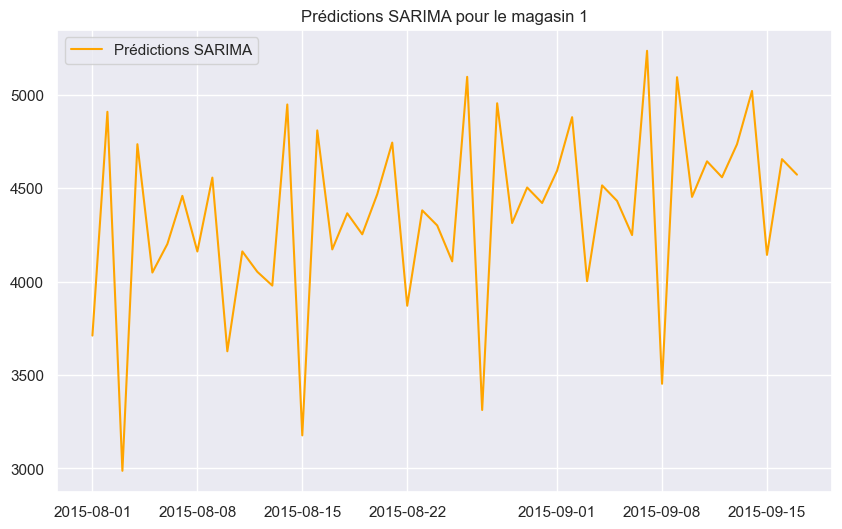

In [853]:
# Par exemple, le magasin 1

store_to_plot = 1 
plt.figure(figsize=(10, 6))
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]

# Tracer le graphique 
plt.plot(store_test_data['Date'], store_test_data['Predicted_Sales'], label='Prédictions SARIMA', color='orange')
plt.title(f'Prédictions SARIMA pour le magasin {store_to_plot}')
plt.legend()
plt.show()

In [889]:
# Calcul variation 

store_to_plot = 1 

# Filtrer les données pour le magasin spécifique
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]

# Convertir la colonne 'Date' en type datetime
store_test_data['Date'] = pd.to_datetime(store_test_data['Date'])

# Filtrer les données entre le 2 août 2015 et le 17 septembre 2015
start_date = '2015-08-02'
end_date = '2015-09-17'
filtered_data = store_test_data[(store_test_data['Date'] >= start_date) & (store_test_data['Date'] <= end_date)]

# Vérifier si les dates du 1er août et du 30 septembre existent dans les données filtrées
if '2015-08-02' in filtered_data['Date'].values and '2015-09-17' in filtered_data['Date'].values:
    # Obtenir les valeurs de Predicted_Sales pour le 1er août et le 30 septembre
    sales_start = filtered_data[filtered_data['Date'] == '2015-08-02']['Predicted_Sales'].iloc[0]
    sales_end = filtered_data[filtered_data['Date'] == '2015-09-17']['Predicted_Sales'].iloc[0]

    # Calculer la variation en valeur absolue
    absolute_variation = abs(sales_end - sales_start)

    # Calculer la variation en valeur relative
    relative_variation = (sales_end - sales_start) / sales_start

    # Afficher les résultats
    print(f"Valeur de Predicted_Sales le 2 août 2015 : {sales_start}")
    print(f"Valeur de Predicted_Sales le 17 septembre 2015 : {sales_end}")
    print(f"Variation en valeur absolue : {absolute_variation}")
    print(f"Variation en valeur relative : {relative_variation * 100:.2f}%")
else:
    print("Les dates spécifiées ne sont pas présentes dans les données filtrées.")

Les dates spécifiées ne sont pas présentes dans les données filtrées.


In [885]:
# Convertir la colonne 'Date' en type datetime, en supprimant l'heure (si présente)
df_test_with_predictions['Date'] = pd.to_datetime(df_test_with_predictions['Date']).dt.date

# Vérifier la dernière date dans le dataframe
last_date = df_test_with_predictions['Date'].max()
print(f"La dernière date dans le dataframe est : {last_date}")

# Filtrer les données entre le 1er août 2015 et le 30 septembre 2015
start_date = pd.to_datetime('2015-08-01').date()  # Supprimer l'heure pour éviter toute différence
end_date = pd.to_datetime('2015-09-30').date()

filtered_data = df_test_with_predictions[(df_test_with_predictions['Date'] >= start_date) & (df_test_with_predictions['Date'] <= end_date)]

# Vérifier si les dates spécifiques sont dans filtered_data
print(filtered_data['Date'].unique())  # Affiche les dates uniques présentes dans filtered_data

# Obtenir les valeurs de Predicted_Sales pour le 1er août et le 30 septembre
if start_date in filtered_data['Date'].values and end_date in filtered_data['Date'].values:
    sales_start = filtered_data[filtered_data['Date'] == start_date]['Predicted_Sales'].iloc[0]
    sales_end = filtered_data[filtered_data['Date'] == end_date]['Predicted_Sales'].iloc[0]

    # Calculer la variation en valeur absolue
    absolute_variation = abs(sales_end - sales_start)

    # Calculer la variation en valeur relative
    relative_variation = (sales_end - sales_start) / sales_start

    # Afficher les résultats
    print(f"Valeur de Predicted_Sales le 1er août 2015 : {sales_start}")
    print(f"Valeur de Predicted_Sales le 30 septembre 2015 : {sales_end}")
    print(f"Variation en valeur absolue : {absolute_variation}")
    print(f"Variation en valeur relative : {relative_variation * 100:.2f}%")
else:
    print(f"Les dates spécifiées ({start_date} et {end_date}) ne sont pas présentes dans filtered_data.")

La dernière date dans le dataframe est : 2015-09-17
[datetime.date(2015, 9, 17) datetime.date(2015, 9, 16)
 datetime.date(2015, 9, 15) datetime.date(2015, 9, 14)
 datetime.date(2015, 9, 13) datetime.date(2015, 9, 12)
 datetime.date(2015, 9, 11) datetime.date(2015, 9, 10)
 datetime.date(2015, 9, 9) datetime.date(2015, 9, 8)
 datetime.date(2015, 9, 7) datetime.date(2015, 9, 6)
 datetime.date(2015, 9, 5) datetime.date(2015, 9, 4)
 datetime.date(2015, 9, 3) datetime.date(2015, 9, 2)
 datetime.date(2015, 9, 1) datetime.date(2015, 8, 31)
 datetime.date(2015, 8, 30) datetime.date(2015, 8, 29)
 datetime.date(2015, 8, 28) datetime.date(2015, 8, 27)
 datetime.date(2015, 8, 26) datetime.date(2015, 8, 25)
 datetime.date(2015, 8, 24) datetime.date(2015, 8, 23)
 datetime.date(2015, 8, 22) datetime.date(2015, 8, 21)
 datetime.date(2015, 8, 20) datetime.date(2015, 8, 19)
 datetime.date(2015, 8, 18) datetime.date(2015, 8, 17)
 datetime.date(2015, 8, 16) datetime.date(2015, 8, 15)
 datetime.date(2015, 8

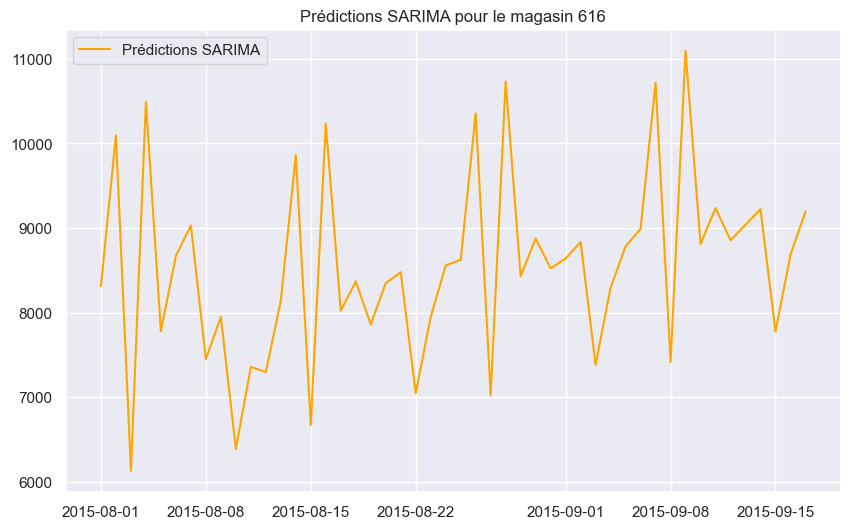

In [899]:
# Autre exemple, le magasin 634 
store_to_plot = 616
plt.figure(figsize=(10, 6))
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]
plt.plot(store_test_data['Date'], store_test_data['Predicted_Sales'], label='Prédictions SARIMA', color='orange')
plt.title(f'Prédictions SARIMA pour le magasin {store_to_plot}')
plt.legend()
plt.show()

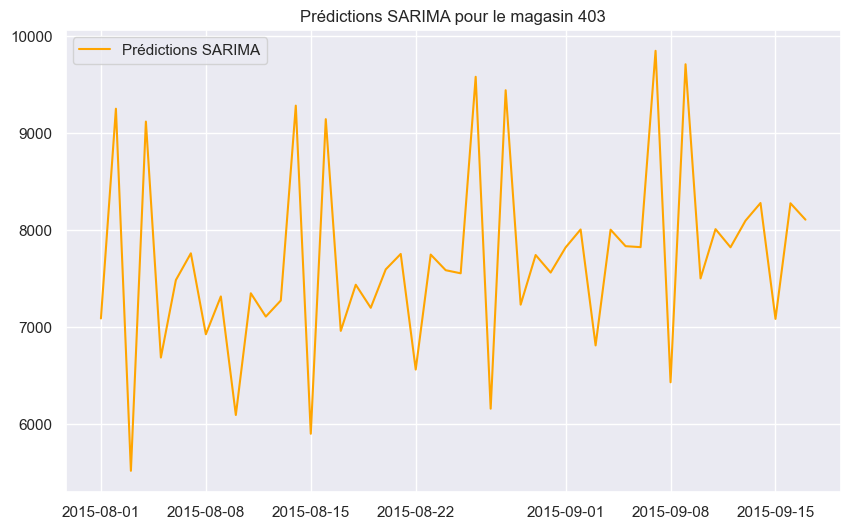

In [893]:
# Autre exemple, le magasin 403
store_to_plot = 403
plt.figure(figsize=(10, 6))
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]
plt.plot(store_test_data['Date'], store_test_data['Predicted_Sales'], label='Prédictions SARIMA', color='orange')
plt.title(f'Prédictions SARIMA pour le magasin {store_to_plot}')
plt.legend()
plt.show()

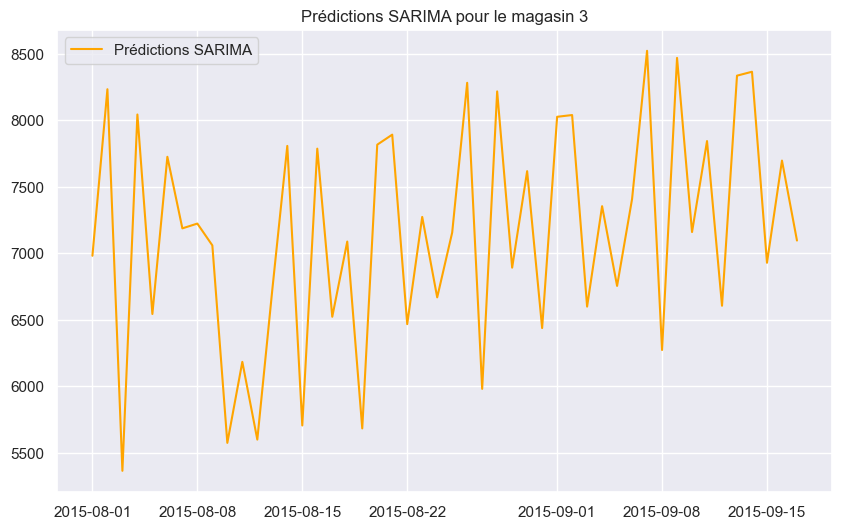

In [901]:
# Autre exemple, le magasin 3
store_to_plot = 3
plt.figure(figsize=(10, 6))
store_test_data = df_test_with_predictions[df_test_with_predictions['Store'] == store_to_plot]
plt.plot(store_test_data['Date'], store_test_data['Predicted_Sales'], label='Prédictions SARIMA', color='orange')
plt.title(f'Prédictions SARIMA pour le magasin {store_to_plot}')
plt.legend()
plt.show()